In [1]:
# Step 4 follow-up: Expanded regression and mechanism-of-action analysis
# Using ompounds w/ at least 20 profiles 

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display



# Locate project folders


cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    # Notebook is being run from the project root
    PROJECT_ROOT = cwd
    DATA_DIR = cwd / "data"

elif (cwd / "step3_multimodal").exists():
    # Notebook is being run from the data folder
    DATA_DIR = cwd
    PROJECT_ROOT = cwd.parent

else:
    raise FileNotFoundError(
        "Could not locate the project folders.\n"
        f"Current folder: {cwd}\n"
        "Expected either data/step3_multimodal or step3_multimodal."
    )


STEP3_DIR = DATA_DIR / "step3_multimodal"
MODEL_DIR = PROJECT_ROOT / "models"

OUTPUT_DIR = STEP3_DIR / "step4_expanded_n20"
FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)



# Analysis settings


MIN_PROFILES = 20

TARGET_COL = "source_normalized_inverted_score"

RANDOM_STATE = 42



# Required input files


SCORE_PATH = (
    STEP3_DIR
    / "step3_compound_predictability_latent256_final_scores.csv"
)

EMBEDDING_PATH = (
    DATA_DIR
    / "step1_embeddings"
    / "step1_drug_embeddings_128.npy"
)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

print("\nScore file:")
print(SCORE_PATH)
print("Exists:", SCORE_PATH.exists())

print("\nEmbedding file:")
print(EMBEDDING_PATH)
print("Exists:", EMBEDDING_PATH.exists())

assert SCORE_PATH.exists(), (
    f"Missing score file: {SCORE_PATH}"
)

assert EMBEDDING_PATH.exists(), (
    f"Missing embedding file: {EMBEDDING_PATH}"
)



# Load Step 3 compound-level predictability scores


scores = pd.read_csv(
    SCORE_PATH,
    low_memory=False,
)

required_columns = [
    "compound_embedding_row_index",
    "compound_name",
    "n_profiles",
    TARGET_COL,
]

missing_columns = [
    column
    for column in required_columns
    if column not in scores.columns
]

if missing_columns:
    raise KeyError(
        "The score table is missing required columns: "
        f"{missing_columns}"
    )


compound_table = (
    scores
    .dropna(subset=required_columns)
    .copy()
)

compound_table["compound_embedding_row_index"] = (
    compound_table["compound_embedding_row_index"]
    .astype(int)
)

compound_table["n_profiles"] = (
    compound_table["n_profiles"]
    .astype(int)
)

compound_table = compound_table.reset_index(
    drop=True
)



# Load only the necessary Step 1 embeddings


all_embeddings = np.load(
    EMBEDDING_PATH,
    mmap_mode="r",
)

embedding_indices = (
    compound_table["compound_embedding_row_index"]
    .to_numpy(dtype=int)
)

if embedding_indices.min() < 0:
    raise IndexError(
        "A negative compound embedding index was found."
    )

if embedding_indices.max() >= all_embeddings.shape[0]:
    raise IndexError(
        "At least one compound embedding index is outside "
        "the saved embedding array."
    )

X_all = np.asarray(
    all_embeddings[embedding_indices],
    dtype=np.float32,
)



# Select the expanded n_profiles >= 20 cohort


analysis_mask = (
    compound_table["n_profiles"] >= MIN_PROFILES
).to_numpy()

X = X_all[analysis_mask]

y = (
    compound_table.loc[
        analysis_mask,
        TARGET_COL,
    ]
    .to_numpy(dtype=np.float32)
)

analysis_table = (
    compound_table.loc[
        analysis_mask,
        required_columns,
    ]
    .reset_index(drop=True)
)



# Validate the analysis dataset


assert X.shape[0] == len(analysis_table)
assert X.shape[1] == 128
assert y.shape == (len(analysis_table),)

assert np.isfinite(X).all()
assert np.isfinite(y).all()

assert (
    analysis_table["compound_embedding_row_index"]
    .is_unique
), "Duplicate compound embedding indices were found."


print("\nSetup complete")
print("-" * 50)

print("Minimum profiles:", MIN_PROFILES)
print("Eligible compounds:", len(analysis_table))
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print(
    "Minimum observed profile count:",
    analysis_table["n_profiles"].min(),
)

print(
    "Median profile count:",
    analysis_table["n_profiles"].median(),
)

print(
    "Maximum profile count:",
    analysis_table["n_profiles"].max(),
)

print(
    "Mean predictability score:",
    round(float(y.mean()), 4),
)

print(
    "Predictability standard deviation:",
    round(float(y.std()), 4),
)


if len(analysis_table) != 801:
    print(
        "\nNOTE: The previous threshold analysis produced "
        "801 compounds at n_profiles >= 20."
    )
    print(
        "The current result differs, so confirm that the same "
        "Step 3 score file is being used before continuing."
    )


display(
    analysis_table.head()
)

display(
    analysis_table[
        ["n_profiles", TARGET_COL]
    ].describe()
)

Project root: /Users/mell/predicting-predictability
Data directory: /Users/mell/predicting-predictability/data

Score file:
/Users/mell/predicting-predictability/data/step3_multimodal/step3_compound_predictability_latent256_final_scores.csv
Exists: True

Embedding file:
/Users/mell/predicting-predictability/data/step1_embeddings/step1_drug_embeddings_128.npy
Exists: True

Setup complete
--------------------------------------------------
Minimum profiles: 20
Eligible compounds: 801
Feature matrix shape: (801, 128)
Target shape: (801,)
Minimum observed profile count: 20
Median profile count: 74.0
Maximum profile count: 3036
Mean predictability score: 0.8268
Predictability standard deviation: 0.0891


,compound_embedding_row_index,compound_name,n_profiles,source_normalized_inverted_score
0,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.969265
1,5134,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.960813
2,5150,Doxycycline (monohydrate); Invertin,139,0.946269
3,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.942327
4,3111,Temuterkib,143,0.940575


,n_profiles,source_normalized_inverted_score
count,801.000000,801.000000
mean,109.344569,0.826764
std,176.879220,0.089164
min,20.000000,0.300781
25%,33.000000,0.781435
50%,74.000000,0.836058
75%,142.000000,0.887230
max,3036.000000,1.000000


In [3]:
# Generate repeated out-of-fold predictions for all 801 compounds

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from scipy.stats import spearmanr



# Cross-validation settings


N_SPLITS = 5
N_REPEATS = 5

n_compounds = len(analysis_table)

# One row per repeat, one column per compound
oof_prediction_matrix = np.full(
    shape=(N_REPEATS, n_compounds),
    fill_value=np.nan,
    dtype=np.float32,
)

repeat_metric_rows = []



# Repeated five-fold out-of-fold prediction


for repeat_number in range(N_REPEATS):

    print(
        f"\nRepeat {repeat_number + 1} "
        f"of {N_REPEATS}"
    )

    cv = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + repeat_number,
    )

    for fold_number, (
        train_indices,
        test_indices,
    ) in enumerate(
        cv.split(X),
        start=1,
    ):

        model = ExtraTreesRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=3,
            random_state=(
                RANDOM_STATE
                + repeat_number * 100
                + fold_number
            ),
            n_jobs=-1,
        )

        model.fit(
            X[train_indices],
            y[train_indices],
        )

        fold_predictions = model.predict(
            X[test_indices]
        )

        oof_prediction_matrix[
            repeat_number,
            test_indices,
        ] = fold_predictions

        print(
            f"  Fold {fold_number}: "
            f"{len(train_indices)} train, "
            f"{len(test_indices)} test"
        )


    # Confirm every compound received one prediction
    # during this repeat
    assert np.isfinite(
        oof_prediction_matrix[repeat_number]
    ).all()

    repeat_predictions = (
        oof_prediction_matrix[repeat_number]
    )

    repeat_r2 = r2_score(
        y,
        repeat_predictions,
    )

    repeat_spearman = spearmanr(
        y,
        repeat_predictions,
    ).correlation

    repeat_mae = mean_absolute_error(
        y,
        repeat_predictions,
    )

    repeat_rmse = np.sqrt(
        mean_squared_error(
            y,
            repeat_predictions,
        )
    )

    repeat_metric_rows.append({
        "repeat": repeat_number + 1,
        "n_compounds": n_compounds,
        "n_splits": N_SPLITS,
        "r2": repeat_r2,
        "spearman": repeat_spearman,
        "mae": repeat_mae,
        "rmse": repeat_rmse,
    })

    print(
        f"  Repeat R²: {repeat_r2:.3f}"
    )

    print(
        f"  Repeat Spearman: "
        f"{repeat_spearman:.3f}"
    )



# Average each compound's predictions across repeats


oof_prediction_mean = (
    oof_prediction_matrix.mean(axis=0)
)

oof_prediction_sd = (
    oof_prediction_matrix.std(axis=0)
)



# Overall performance using averaged OOF predictions


overall_r2 = r2_score(
    y,
    oof_prediction_mean,
)

overall_spearman = spearmanr(
    y,
    oof_prediction_mean,
).correlation

overall_mae = mean_absolute_error(
    y,
    oof_prediction_mean,
)

overall_rmse = np.sqrt(
    mean_squared_error(
        y,
        oof_prediction_mean,
    )
)



# Performance on high-confidence compounds only


high_confidence_mask = (
    analysis_table["n_profiles"] >= 100
).to_numpy()

high_confidence_r2 = r2_score(
    y[high_confidence_mask],
    oof_prediction_mean[high_confidence_mask],
)

high_confidence_spearman = spearmanr(
    y[high_confidence_mask],
    oof_prediction_mean[high_confidence_mask],
).correlation

high_confidence_mae = mean_absolute_error(
    y[high_confidence_mask],
    oof_prediction_mean[high_confidence_mask],
)

high_confidence_rmse = np.sqrt(
    mean_squared_error(
        y[high_confidence_mask],
        oof_prediction_mean[high_confidence_mask],
    )
)



# Create compound-level prediction table


oof_results = analysis_table.copy()

oof_results["actual_predictability"] = y

oof_results["predicted_predictability"] = (
    oof_prediction_mean
)

oof_results["prediction_sd"] = (
    oof_prediction_sd
)

oof_results["residual"] = (
    oof_results["actual_predictability"]
    - oof_results["predicted_predictability"]
)

oof_results["absolute_error"] = (
    oof_results["residual"].abs()
)

oof_results["predicted_rank"] = (
    oof_results["predicted_predictability"]
    .rank(
        ascending=False,
        method="average",
    )
)



# Save outputs


OOF_RESULTS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions.csv"
)

REPEAT_METRICS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_repeat_metrics.csv"
)

SUMMARY_METRICS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_summary_metrics.csv"
)

PREDICTION_MATRIX_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_prediction_matrix.npy"
)


oof_results.to_csv(
    OOF_RESULTS_PATH,
    index=False,
)

repeat_metrics = pd.DataFrame(
    repeat_metric_rows
)

repeat_metrics.to_csv(
    REPEAT_METRICS_PATH,
    index=False,
)

np.save(
    PREDICTION_MATRIX_PATH,
    oof_prediction_matrix,
)


summary_metrics = pd.DataFrame([
    {
        "evaluation_group": "all_n_profiles_greater_equal_20",
        "n_compounds": len(y),
        "r2": overall_r2,
        "spearman": overall_spearman,
        "mae": overall_mae,
        "rmse": overall_rmse,
    },
    {
        "evaluation_group": "high_confidence_n_profiles_greater_equal_100",
        "n_compounds": int(
            high_confidence_mask.sum()
        ),
        "r2": high_confidence_r2,
        "spearman": high_confidence_spearman,
        "mae": high_confidence_mae,
        "rmse": high_confidence_rmse,
    },
])

summary_metrics.to_csv(
    SUMMARY_METRICS_PATH,
    index=False,
)



# Display results


print("\n" + "=" * 60)
print("Repeated out-of-fold evaluation complete")
print("=" * 60)

print("\nAll compounds with n_profiles >= 20")
print("Compounds:", len(y))
print(f"R²:       {overall_r2:.3f}")
print(f"Spearman: {overall_spearman:.3f}")
print(f"MAE:      {overall_mae:.4f}")
print(f"RMSE:     {overall_rmse:.4f}")

print("\nHigh-confidence subset with n_profiles >= 100")
print(
    "Compounds:",
    high_confidence_mask.sum(),
)
print(f"R²:       {high_confidence_r2:.3f}")
print(
    f"Spearman: "
    f"{high_confidence_spearman:.3f}"
)
print(f"MAE:      {high_confidence_mae:.4f}")
print(
    f"RMSE:     "
    f"{high_confidence_rmse:.4f}"
)

print("\nSaved prediction table:")
print(OOF_RESULTS_PATH)

print("\nSaved summary metrics:")
print(SUMMARY_METRICS_PATH)

display(summary_metrics)

display(
    oof_results[
        [
            "compound_name",
            "n_profiles",
            "actual_predictability",
            "predicted_predictability",
            "prediction_sd",
            "absolute_error",
        ]
    ]
    .sort_values(
        "predicted_predictability",
        ascending=False,
    )
    .head(10)
)


Repeat 1 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test
  Repeat R²: 0.129
  Repeat Spearman: 0.361

Repeat 2 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test
  Repeat R²: 0.135
  Repeat Spearman: 0.382

Repeat 3 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test
  Repeat R²: 0.120
  Repeat Spearman: 0.358

Repeat 4 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test
  Repeat R²: 0.134
  Repeat Spearman: 0.364

Repeat 5 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test

,evaluation_group,n_compounds,r2,spearman,mae,rmse
0,all_n_profiles_greater_equal_20,801,0.136042,0.379465,0.063266,0.082825
1,high_confidence_n_profiles_greater_equal_100,349,0.133087,0.372285,0.060709,0.074288


,compound_name,n_profiles,actual_predictability,predicted_predictability,prediction_sd,absolute_error
376,"(7R,9S)-7-[(2R,4S,5S,6S)-4-amino-5-hydroxy-6-m...",386,0.972176,0.962845,0.009997,0.009331
267,Epirubicin; epirubicin,194,0.983716,0.961449,0.008261,0.022267
1,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.960813,0.958234,0.007328,0.002579
270,Idarubicin; idarubicin,134,0.975772,0.956359,0.005216,0.019413
262,"(7R,9S)-9-acetyl-7-[[(2R,4S,5S,6S)-4-amino-5-h...",325,0.993675,0.954556,0.003145,0.039120
0,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.969265,0.953787,0.006604,0.015478
10,Topotecan (hydrochloride); Topotecan Hydrochlo...,142,0.911250,0.933917,0.022671,0.022667
263,Geldanamycin; geldanamycin,938,0.987674,0.926570,0.008105,0.061103
266,"Tanespimycin; [(4E,6Z,8S,9S,10E,12S,13R,14S,16...",645,0.995693,0.923778,0.014941,0.071914
68,Ouabain (Octahydrate); Ouabain Octahydrate,144,0.844328,0.923442,0.028146,0.079114


,predicted_quintile,n_compounds,mean_actual_predictability,median_actual_predictability,std_actual_predictability,mean_predicted_predictability
0,Least\npredictable,161,0.781380,0.801439,0.088549,0.788727
1,Lower,160,0.808978,0.817731,0.085349,0.812418
2,Middle,160,0.826404,0.839005,0.083528,0.824415
3,Higher,160,0.844032,0.861938,0.079800,0.837979
4,Most\npredictable,160,0.873311,0.882362,0.081221,0.871648


Kruskal-Wallis statistic: 113.553
Kruskal-Wallis p-value: 1.271e-23


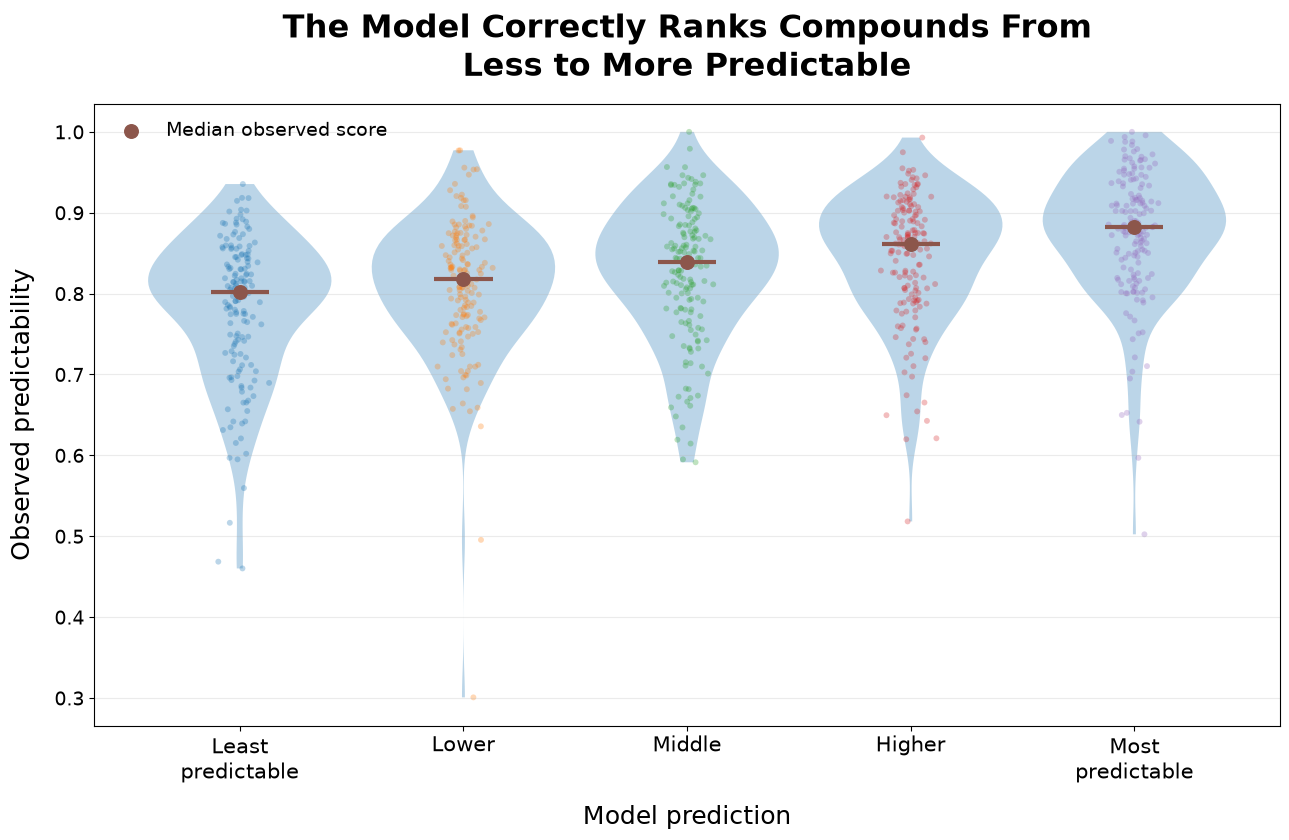


Saved violin plot:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_by_predicted_quintile.png

Saved quintile summary:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_predicted_quintile_summary.csv


In [16]:
# Visualize 

import matplotlib.pyplot as plt
from scipy.stats import kruskal



# Assign compounds to five predicted groups


quintile_labels = [
    "Least\npredictable",
    "Lower",
    "Middle",
    "Higher",
    "Most\npredictable",
]

# Rank first
prediction_rank_for_binning = (
    oof_results["predicted_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

oof_results["predicted_quintile"] = pd.qcut(
    prediction_rank_for_binning,
    q=5,
    labels=quintile_labels,
)

oof_results["predicted_quintile"] = pd.Categorical(
    oof_results["predicted_quintile"],
    categories=quintile_labels,
    ordered=True,
)


# Summarize each group


quintile_summary = (
    oof_results
    .groupby(
        "predicted_quintile",
        observed=False,
    )
    .agg(
        n_compounds=(
            "actual_predictability",
            "size",
        ),
        mean_actual_predictability=(
            "actual_predictability",
            "mean",
        ),
        median_actual_predictability=(
            "actual_predictability",
            "median",
        ),
        std_actual_predictability=(
            "actual_predictability",
            "std",
        ),
        mean_predicted_predictability=(
            "predicted_predictability",
            "mean",
        ),
    )
    .reset_index()
)

display(quintile_summary)


# Prepare values for plotting


violin_values = [
    oof_results.loc[
        oof_results["predicted_quintile"] == label,
        "actual_predictability",
    ].to_numpy()
    for label in quintile_labels
]


# Test whether the five groups differ overall


kruskal_result = kruskal(
    *violin_values
)

print(
    "Kruskal-Wallis statistic:",
    round(float(kruskal_result.statistic), 3),
)

print(
    "Kruskal-Wallis p-value:",
    f"{kruskal_result.pvalue:.3e}",
)



# Create clearer violin plot


fig, ax = plt.subplots(
    figsize=(13, 8.5)
)

positions = np.arange(
    1,
    len(quintile_labels) + 1,
)

# Violin distributions
ax.violinplot(
    violin_values,
    positions=positions,
    widths=0.82,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)


# Add individual compounds 
rng = np.random.default_rng(
    RANDOM_STATE
)

for position, values in enumerate(
    violin_values,
    start=1,
):
    jitter = rng.normal(
        loc=position,
        scale=0.045,
        size=len(values),
    )

    ax.scatter(
        jitter,
        values,
        s=18,
        alpha=0.30,
        edgecolors="none",
    )


# Add median lines and points using the same color
median_color = "tab:brown"

ax.hlines(
    y=group_medians,
    xmin=positions - 0.13,
    xmax=positions + 0.13,
    color=median_color,
    linewidth=3,
    zorder=5,
)

ax.scatter(
    positions,
    group_medians,
    s=95,
    color=median_color,
    zorder=6,
    label="Median observed score",
)


# Larger and clearer text


ax.set_xticks(
    positions
)

ax.set_xticklabels(
    quintile_labels,
    fontsize=15,
)

ax.set_xlabel(
    "Model prediction",
    fontsize=18,
    labelpad=14,
)

ax.set_ylabel(
    "Observed predictability",
    fontsize=18,
    labelpad=14,
)

ax.set_title(
    "The Model Correctly Ranks Compounds From\n"
    "Less to More Predictable",
    fontsize=23,
    pad=20,
    fontweight="bold",
)

ax.tick_params(
    axis="y",
    labelsize=14,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    fontsize=14,
    frameon=False,
    loc="upper left",
)

fig.tight_layout()



# Save figure and tables


VIOLIN_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_observed_by_predicted_quintile.png"
)

VIOLIN_FIGURE_PDF_PATH = (
    FIG_DIR
    / "step4_n20_observed_by_predicted_quintile.pdf"
)

QUINTILE_SUMMARY_PATH = (
    OUTPUT_DIR
    / "step4_n20_predicted_quintile_summary.csv"
)

OOF_RESULTS_WITH_GROUPS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions_with_groups.csv"
)


fig.savefig(
    VIOLIN_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    VIOLIN_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

quintile_summary.to_csv(
    QUINTILE_SUMMARY_PATH,
    index=False,
)

oof_results.to_csv(
    OOF_RESULTS_WITH_GROUPS_PATH,
    index=False,
)

plt.show()


print("\nSaved violin plot:")
print(VIOLIN_FIGURE_PATH)

print("\nSaved quintile summary:")
print(QUINTILE_SUMMARY_PATH)

In [9]:
# MoA analysis, Step 1

import numpy as np
import pandas as pd
from pathlib import Path



# Load Step 1 compound metadata


STEP1_METADATA_PATH = (
    DATA_DIR
    / "step1_embeddings"
    / "step1_compound_embeddings_metadata.csv"
)

print("Step 1 metadata file:")
print(STEP1_METADATA_PATH)
print("Exists:", STEP1_METADATA_PATH.exists())

assert STEP1_METADATA_PATH.exists(), (
    f"Missing Step 1 metadata: {STEP1_METADATA_PATH}"
)


step1_metadata = pd.read_csv(
    STEP1_METADATA_PATH,
    usecols=lambda column: column in {
        "embedding_row_index",
        "compound_name",
        "canonical_smiles",
        "moa",
        "target",
    },
    low_memory=False,
)

required_metadata_columns = {
    "embedding_row_index",
    "moa",
}

missing_metadata_columns = (
    required_metadata_columns
    - set(step1_metadata.columns)
)

assert not missing_metadata_columns, (
    "Step 1 metadata is missing columns: "
    f"{sorted(missing_metadata_columns)}"
)


step1_metadata = (
    step1_metadata
    .rename(
        columns={
            "embedding_row_index":
                "compound_embedding_row_index",
        }
    )
    .drop_duplicates(
        subset="compound_embedding_row_index",
        keep="first",
    )
    .copy()
)

step1_metadata["compound_embedding_row_index"] = (
    step1_metadata["compound_embedding_row_index"]
    .astype(int)
)



# Recreate the five model-predicted groups


prediction_rank_for_binning = (
    oof_results["predicted_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

model_group_labels = [
    "Least predictable",
    "Lower",
    "Middle",
    "Higher",
    "Most predictable",
]

moa_results = oof_results.copy()

moa_results["model_prediction_group"] = pd.qcut(
    prediction_rank_for_binning,
    q=5,
    labels=model_group_labels,
)

moa_results["model_prediction_group"] = pd.Categorical(
    moa_results["model_prediction_group"],
    categories=model_group_labels,
    ordered=True,
)



# Merge MoA annotations


moa_results = moa_results.merge(
    step1_metadata[
        [
            "compound_embedding_row_index",
            "moa",
            "target",
        ]
    ],
    on="compound_embedding_row_index",
    how="left",
    validate="one_to_one",
)

assert len(moa_results) == len(oof_results)


# Clean common missing-value strings
missing_annotation_values = {
    "",
    "nan",
    "none",
    "<na>",
    "na",
    "n/a",
    "-",
}

for column in ["moa", "target"]:

    moa_results[column] = (
        moa_results[column]
        .astype("string")
        .str.strip()
    )

    invalid_mask = (
        moa_results[column]
        .str.lower()
        .isin(missing_annotation_values)
        .fillna(False)
    )

    moa_results.loc[
        invalid_mask,
        column,
    ] = pd.NA



# Keep only the least and most predictable groups


extreme_groups = [
    "Least predictable",
    "Most predictable",
]

extreme_results = (
    moa_results[
        moa_results["model_prediction_group"]
        .isin(extreme_groups)
    ]
    .copy()
)

extreme_results["model_prediction_group"] = (
    extreme_results["model_prediction_group"]
    .astype(str)
)

# Summarize annotation coverage


coverage_summary = (
    extreme_results
    .groupby("model_prediction_group")
    .agg(
        n_compounds=(
            "compound_embedding_row_index",
            "nunique",
        ),
        n_with_moa=(
            "moa",
            lambda values: values.notna().sum(),
        ),
        n_with_target=(
            "target",
            lambda values: values.notna().sum(),
        ),
    )
    .reindex(extreme_groups)
    .reset_index()
)

coverage_summary["percent_with_moa"] = (
    100
    * coverage_summary["n_with_moa"]
    / coverage_summary["n_compounds"]
)

coverage_summary["percent_with_target"] = (
    100
    * coverage_summary["n_with_target"]
    / coverage_summary["n_compounds"]
)


print("\nMoA metadata merge complete")
print("-" * 55)
print("All modelled compounds:", len(moa_results))
print("Extreme-group compounds:", len(extreme_results))

display(coverage_summary)

display(
    extreme_results[
        [
            "compound_name",
            "model_prediction_group",
            "predicted_predictability",
            "actual_predictability",
            "moa",
            "target",
        ]
    ]
    .sort_values(
        [
            "model_prediction_group",
            "predicted_predictability",
        ],
        ascending=[True, False],
    )
    .head(20)
)

Step 1 metadata file:
/Users/mell/predicting-predictability/data/step1_embeddings/step1_compound_embeddings_metadata.csv
Exists: True

MoA metadata merge complete
-------------------------------------------------------
All modelled compounds: 801
Extreme-group compounds: 321


,model_prediction_group,n_compounds,n_with_moa,n_with_target,percent_with_moa,percent_with_target
0,Least predictable,161,144,129,89.440994,80.124224
1,Most predictable,160,146,131,91.25,81.875


,compound_name,model_prediction_group,predicted_predictability,actual_predictability,moa,target
49,"Naproxen, (-)-; naproxen",Least predictable,0.805421,0.903755,Cyclooxygenase inhibitor; cyclooxygenase inhib...,"PTGS1 | PTGS2; PTGS1, PTGS2"
154,Darolutamide,Least predictable,0.805265,0.774786,androgen receptor antagonist; inhibitor/antago...,AR
759,4-tert-butyl-N-[2-methyl-3-[4-methyl-6-[4-(mor...,Least predictable,0.805008,0.468567,<NA>,['BTK']
268,"(Z)-3-[3-[3,5-bis(trifluoromethyl)phenyl]-1,2,...",Least predictable,0.805000,0.848897,Exportin 1 inhibitor; exportin antagonist,XPO1; ['XPO1']
739,5-chloro-2-N-[(1S)-1-(5-fluoropyrimidin-2-yl)e...,Least predictable,0.804618,0.819014,JAK inhibitor; Jak2 Inhibitors,JAK1 | JAK2 | JAK3; ['JAK1' 'JAK2']
651,Tamibarotene; tamibarotene,Least predictable,0.804556,0.726672,Retinoid receptor agonist; retinoid receptor a...,"RARA | RARB; RARB, RARA"
470,"1-[2-chloro-4-(6,7-dimethoxyquinolin-4-yl)oxyp...",Least predictable,0.804477,0.847737,Angiogenesis Inhibitors;VEGFR-2 (FLK-1/KDR) In...,FLT1 | FLT4 | KDR | KIT | PDGFRA | PDGFRB; KIT...
482,CGK-733; Diphenyl acetamidotrichloroethyl fluo...,Least predictable,0.804344,0.845304,ATM kinase inhibitor | ATR kinase inhibitor; A...,"ATM | ATR; ATM, ATR"
480,(+-)-Quinacrine; 4-N-(6-chloro-2-methoxyacridi...,Least predictable,0.804167,0.848605,"Cytokine production inhibitor, NFKB pathway in...",AKT1 | MTOR | NFKB1 | PLA2G1B | PLA2G2A | PLA2...
569,thioguanine,Least predictable,0.804137,0.801525,Purine antagonist; purine antagonist,"IMPDH1 | IMPDH2; IMPDH2, IMPDH1"


MoA-annotated compounds by group:


,model_prediction_group,n_annotated_compounds
0,Least predictable,144
1,Most predictable,146



Most common MoAs in the two extreme groups:


,moa_annotation,least_predictable_count,most_predictable_count,least_predictable_percent,most_predictable_percent,total_extreme_count
0,inhibitor/antagonist,23,30,15.972222,20.547945,53
1,unclear,12,16,8.333333,10.958904,28
2,topoisomerase inhibitor,0,11,0.000000,7.534247,11
3,Topoisomerase inhibitor,1,10,0.694444,6.849315,11
4,glucocorticoid receptor agonist,0,11,0.000000,7.534247,11
5,ATPase inhibitor,0,7,0.000000,4.794521,7
6,mTOR inhibitor,0,6,0.000000,4.109589,6
7,activator/agonist,5,1,3.472222,0.684932,6
8,Glucocorticoid receptor agonist,0,6,0.000000,4.109589,6
9,Aurora kinase inhibitor,5,0,3.472222,0.000000,5


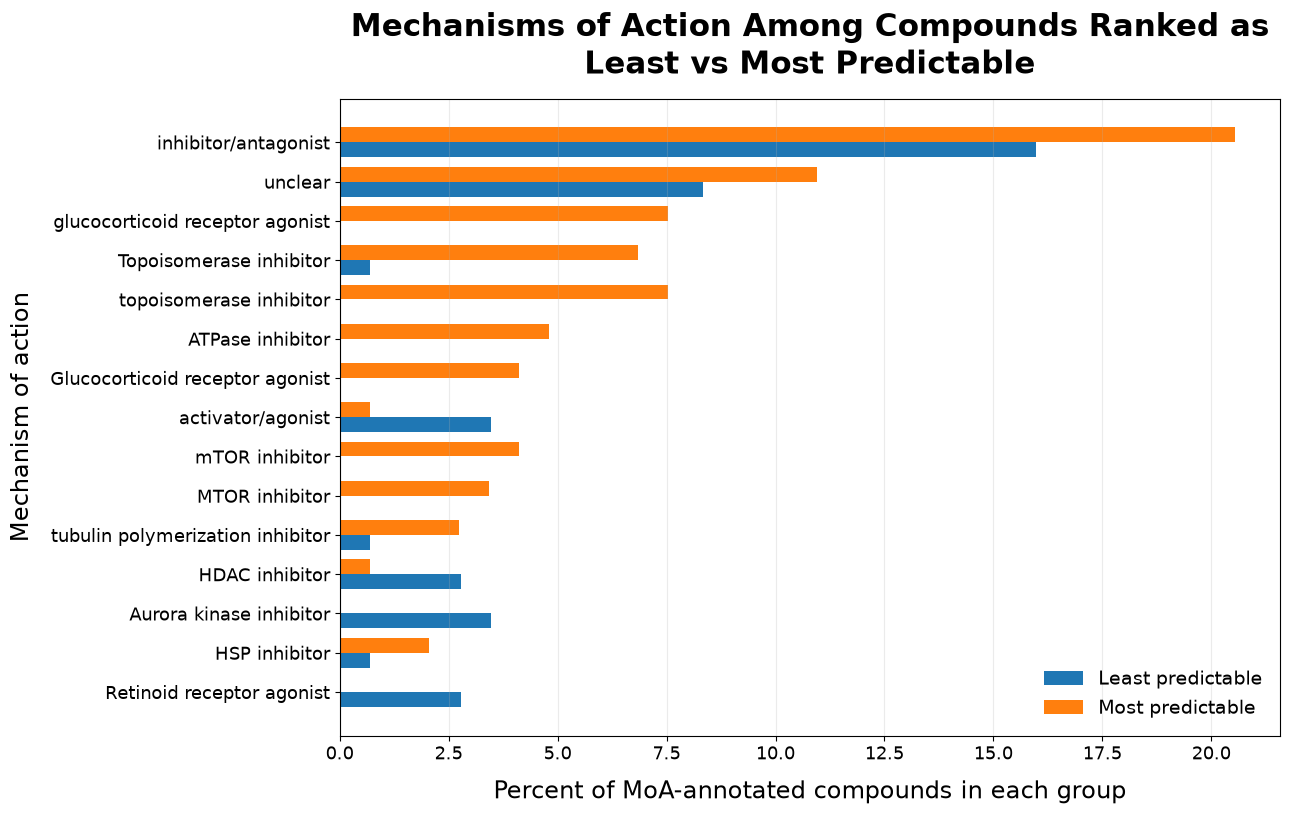


Saved MoA comparison table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_extreme_predicted_group_moa_counts.csv

Saved MoA figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_least_vs_most_predictable_moa.png


In [17]:
# MoA analysis, Step 2

import matplotlib.pyplot as plt


# Split semicolon-separated MoA annotations

def split_moa_annotations(value):
    """
    Return the distinct MoA annotations stored for one compound.
    """

    if pd.isna(value):
        return []

    annotations = []

    for annotation in str(value).split(";"):

        annotation = annotation.strip()

        if (
            annotation
            and annotation.lower()
            not in missing_annotation_values
        ):
            annotations.append(annotation)

    return sorted(set(annotations))


moa_long = (
    extreme_results[
        [
            "compound_embedding_row_index",
            "compound_name",
            "model_prediction_group",
            "moa",
        ]
    ]
    .assign(
        moa_annotation=lambda frame:
            frame["moa"].apply(split_moa_annotations)
    )
    .explode("moa_annotation")
    .dropna(subset=["moa_annotation"])
    .copy()
)

moa_long["moa_annotation"] = (
    moa_long["moa_annotation"]
    .astype(str)
    .str.strip()
)

# Count each MoA no more than once per compound
moa_long = (
    moa_long
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "model_prediction_group",
            "moa_annotation",
        ]
    )
    .reset_index(drop=True)
)


# Count MoA-annotated compounds in each group

annotated_group_sizes = (
    moa_long
    .groupby("model_prediction_group")[
        "compound_embedding_row_index"
    ]
    .nunique()
    .reindex(extreme_groups)
)

print("MoA-annotated compounds by group:")

display(
    annotated_group_sizes
    .rename("n_annotated_compounds")
    .reset_index()
)


# Count compounds carrying each MoA

# NumPy arrays 
moa_counts = pd.crosstab(
    index=moa_long["moa_annotation"].to_numpy(),
    columns=moa_long["model_prediction_group"].to_numpy(),
)

moa_counts.index.name = "moa_annotation"
moa_counts.columns.name = "model_prediction_group"

moa_counts = moa_counts.reindex(
    columns=extreme_groups,
    fill_value=0,
)


# Create comparison table

moa_comparison = moa_counts.copy()

moa_comparison.columns = [
    "least_predictable_count",
    "most_predictable_count",
]

n_annotated_least = int(
    annotated_group_sizes["Least predictable"]
)

n_annotated_most = int(
    annotated_group_sizes["Most predictable"]
)

assert n_annotated_least > 0
assert n_annotated_most > 0


moa_comparison["least_predictable_percent"] = (
    100
    * moa_comparison["least_predictable_count"]
    / n_annotated_least
)

moa_comparison["most_predictable_percent"] = (
    100
    * moa_comparison["most_predictable_count"]
    / n_annotated_most
)

moa_comparison["total_extreme_count"] = (
    moa_comparison["least_predictable_count"]
    + moa_comparison["most_predictable_count"]
)

moa_comparison = (
    moa_comparison
    .sort_values(
        "total_extreme_count",
        ascending=False,
    )
    .reset_index()
)


# Select the most represented MoAs for visualization

N_MOAS_TO_PLOT = 15

plot_table = (
    moa_comparison
    .head(N_MOAS_TO_PLOT)
    .sort_values(
        "total_extreme_count",
        ascending=True,
    )
    .copy()
)

print("\nMost common MoAs in the two extreme groups:")

display(
    moa_comparison.head(25)
)


# Make side-by-side horizontal bar plot

fig_height = max(
    8,
    0.55 * len(plot_table),
)

fig, ax = plt.subplots(
    figsize=(13, fig_height)
)

positions = np.arange(
    len(plot_table)
)

bar_height = 0.38

ax.barh(
    positions - bar_height / 2,
    plot_table["least_predictable_percent"],
    height=bar_height,
    label="Least predictable",
)

ax.barh(
    positions + bar_height / 2,
    plot_table["most_predictable_percent"],
    height=bar_height,
    label="Most predictable",
)

ax.set_yticks(
    positions
)

ax.set_yticklabels(
    plot_table["moa_annotation"],
    fontsize=13,
)

ax.set_xlabel(
    "Percent of MoA-annotated compounds in each group",
    fontsize=17,
    labelpad=12,
)

ax.set_ylabel(
    "Mechanism of action",
    fontsize=17,
    labelpad=12,
)

ax.set_title(
    "Mechanisms of Action Among Compounds Ranked as\n"
    "Least vs Most Predictable",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.tick_params(
    axis="x",
    labelsize=13,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.legend(
    fontsize=14,
    frameon=False,
)

fig.tight_layout()


# Save outputs

MOA_COMPARISON_PATH = (
    OUTPUT_DIR
    / "step4_n20_extreme_predicted_group_moa_counts.csv"
)

MOA_LONG_PATH = (
    OUTPUT_DIR
    / "step4_n20_extreme_predicted_group_moa_long.csv"
)

MOA_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_least_vs_most_predictable_moa.png"
)

MOA_FIGURE_PDF_PATH = (
    FIG_DIR
    / "step4_n20_least_vs_most_predictable_moa.pdf"
)

moa_comparison.to_csv(
    MOA_COMPARISON_PATH,
    index=False,
)

moa_long.to_csv(
    MOA_LONG_PATH,
    index=False,
)

fig.savefig(
    MOA_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    MOA_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved MoA comparison table:")
print(MOA_COMPARISON_PATH)

print("\nSaved MoA figure:")
print(MOA_FIGURE_PATH)

Annotations before cleaning: 485
Annotations after standardization: 465
Specific annotations retained: 378

Compounds with at least one specific MoA:


,model_prediction_group,n_annotated_compounds
0,Least predictable,129
1,Most predictable,140



Cleaned MoA comparison:


,moa_annotation,least_predictable_count,most_predictable_count,least_predictable_percent,most_predictable_percent,total_extreme_count
0,Topoisomerase inhibitor,1,15,0.775194,10.714286,16
1,Glucocorticoid receptor agonist,0,12,0.000000,8.571429,12
2,ATPase inhibitor,0,7,0.000000,5.000000,7
3,mTOR inhibitor,0,6,0.000000,4.285714,6
4,Tubulin polymerization inhibitor,1,4,0.775194,2.857143,5
5,Retinoid receptor agonist,5,0,3.875969,0.000000,5
6,AKT inhibitor,2,3,1.550388,2.142857,5
7,HDAC inhibitor,4,1,3.100775,0.714286,5
8,Aurora kinase inhibitor,5,0,3.875969,0.000000,5
9,Adrenergic receptor agonist,5,0,3.875969,0.000000,5


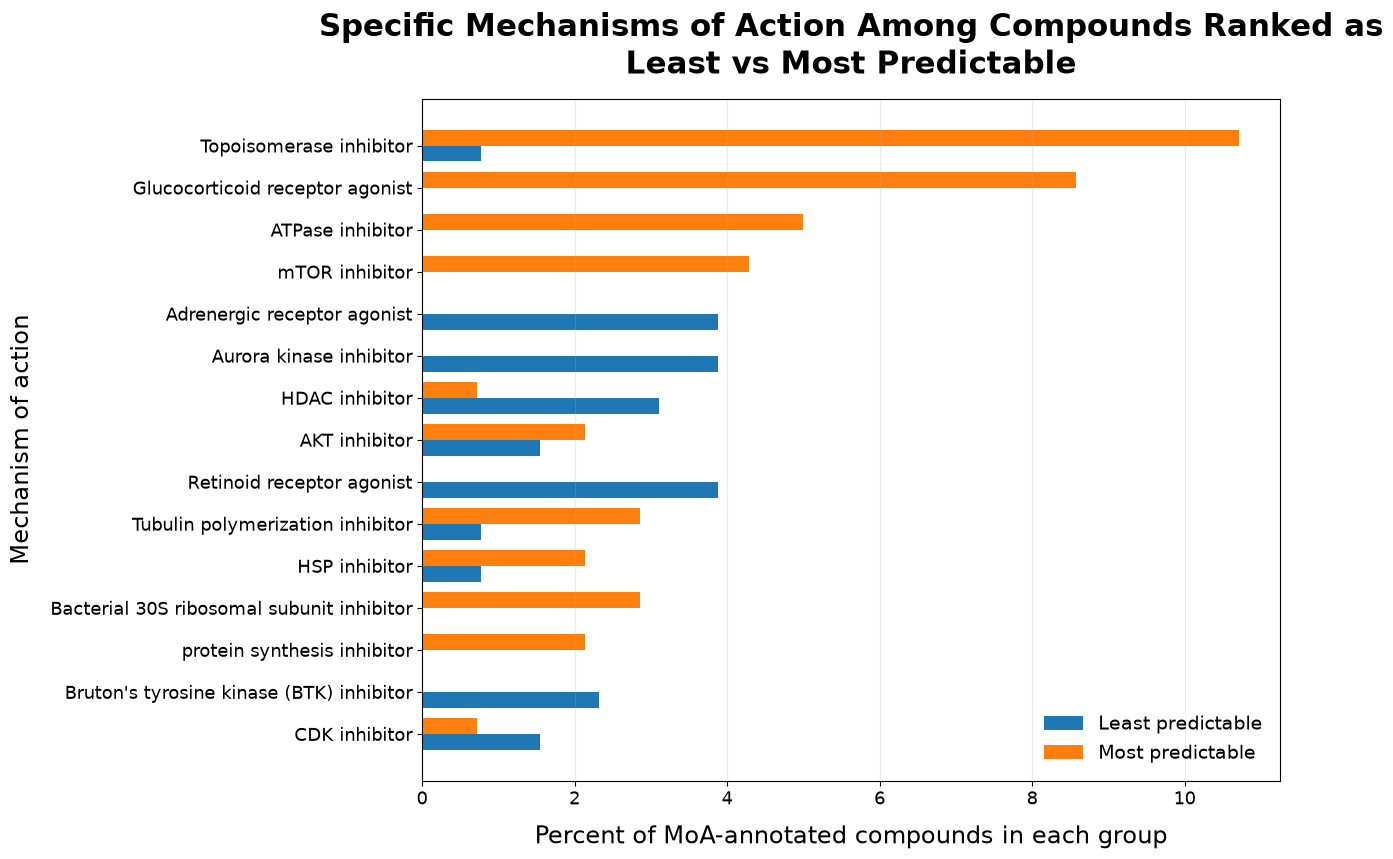


Saved cleaned MoA comparison:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_specific_moa_comparison.csv

Saved cleaned MoA figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_specific_moa_least_vs_most.png


In [19]:
# Clean and standardize MoA labels

import re
import matplotlib.pyplot as plt


# Standardize names

CANONICAL_MOA_NAMES = {
    "topoisomerase inhibitor":
        "Topoisomerase inhibitor",

    "glucocorticoid receptor agonist":
        "Glucocorticoid receptor agonist",

    "mtor inhibitor":
        "mTOR inhibitor",

    "atpase inhibitor":
        "ATPase inhibitor",

    "hdac inhibitor":
        "HDAC inhibitor",

    "hsp inhibitor":
        "HSP inhibitor",

    "akt inhibitor":
        "AKT inhibitor",

    "pi3k inhibitor":
        "PI3K inhibitor",

    "ikk inhibitor":
        "IKK inhibitor",

    "hmgcr inhibitor":
        "HMGCR inhibitor",

    "bruton's tyrosine kinase (btk) inhibitor":
        "Bruton's tyrosine kinase (BTK) inhibitor",

    "bacterial 30s ribosomal subunit inhibitor":
        "Bacterial 30S ribosomal subunit inhibitor",

    "glycogen synthase kinase inhibitor":
        "Glycogen synthase kinase inhibitor",

    "aurora kinase inhibitor":
        "Aurora kinase inhibitor",

    "tubulin polymerization inhibitor":
        "Tubulin polymerization inhibitor",

    "retinoid receptor agonist":
        "Retinoid receptor agonist",

    "adrenergic receptor agonist":
        "Adrenergic receptor agonist",

    "inhibitors of signal transduction pathways":
        "Inhibitors of signal transduction pathways",

    "inhibitor/antagonist":
        "Inhibitor/antagonist",

    "activator/agonist":
        "Activator/agonist",

    "unclear":
        "Unclear",
}


def standardize_moa_name(value):
    """
    Standardize spacing, capitalization, and known acronym variants.
    """

    if pd.isna(value):
        return pd.NA

    cleaned = re.sub(
        r"\s+",
        " ",
        str(value).strip(),
    )

    key = cleaned.casefold()

    return CANONICAL_MOA_NAMES.get(
        key,
        cleaned,
    )


moa_long_clean = moa_long.copy()

moa_long_clean["moa_annotation"] = (
    moa_long_clean["moa_annotation"]
    .apply(standardize_moa_name)
)

moa_long_clean = (
    moa_long_clean
    .dropna(subset=["moa_annotation"])
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "model_prediction_group",
            "moa_annotation",
        ]
    )
    .reset_index(drop=True)
)


# Remove vague/non-specific annotation categories

NON_SPECIFIC_MOAS = {
    "Unclear",
    "Inhibitor/antagonist",
    "Activator/agonist",
}

moa_long_specific = (
    moa_long_clean[
        ~moa_long_clean["moa_annotation"]
        .isin(NON_SPECIFIC_MOAS)
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "Annotations before cleaning:",
    len(moa_long),
)

print(
    "Annotations after standardization:",
    len(moa_long_clean),
)

print(
    "Specific annotations retained:",
    len(moa_long_specific),
)


# Count compounds with at least one specific MoA

annotated_group_sizes = (
    moa_long_specific
    .groupby("model_prediction_group")[
        "compound_embedding_row_index"
    ]
    .nunique()
    .reindex(extreme_groups)
)

print("\nCompounds with at least one specific MoA:")

display(
    annotated_group_sizes
    .rename("n_annotated_compounds")
    .reset_index()
)


# Count compounds carrying each specific MoA

moa_counts = pd.crosstab(
    index=(
        moa_long_specific["moa_annotation"]
        .to_numpy()
    ),
    columns=(
        moa_long_specific["model_prediction_group"]
        .to_numpy()
    ),
)

moa_counts.index.name = "moa_annotation"

moa_counts.columns.name = (
    "model_prediction_group"
)

moa_counts = moa_counts.reindex(
    columns=extreme_groups,
    fill_value=0,
)


# Build cleaned comparison table

moa_comparison = moa_counts.copy()

moa_comparison.columns = [
    "least_predictable_count",
    "most_predictable_count",
]

n_annotated_least = int(
    annotated_group_sizes["Least predictable"]
)

n_annotated_most = int(
    annotated_group_sizes["Most predictable"]
)

assert n_annotated_least > 0
assert n_annotated_most > 0


moa_comparison["least_predictable_percent"] = (
    100
    * moa_comparison["least_predictable_count"]
    / n_annotated_least
)

moa_comparison["most_predictable_percent"] = (
    100
    * moa_comparison["most_predictable_count"]
    / n_annotated_most
)

moa_comparison["total_extreme_count"] = (
    moa_comparison["least_predictable_count"]
    + moa_comparison["most_predictable_count"]
)

moa_comparison = (
    moa_comparison
    .sort_values(
        "total_extreme_count",
        ascending=False,
    )
    .reset_index()
)


print("\nCleaned MoA comparison:")

display(
    moa_comparison.head(25)
)


# Select MoAs for the cleaned figure

N_MOAS_TO_PLOT = 15

plot_table = (
    moa_comparison
    .head(N_MOAS_TO_PLOT)
    .sort_values(
        "total_extreme_count",
        ascending=True,
    )
    .copy()
)


# Create cleaned comparison figure

fig_height = max(
    8,
    0.58 * len(plot_table),
)

fig, ax = plt.subplots(
    figsize=(13, fig_height)
)

positions = np.arange(
    len(plot_table)
)

bar_height = 0.38

ax.barh(
    positions - bar_height / 2,
    plot_table["least_predictable_percent"],
    height=bar_height,
    label="Least predictable",
)

ax.barh(
    positions + bar_height / 2,
    plot_table["most_predictable_percent"],
    height=bar_height,
    label="Most predictable",
)

ax.set_yticks(
    positions
)

ax.set_yticklabels(
    plot_table["moa_annotation"],
    fontsize=13,
)

ax.set_xlabel(
    "Percent of MoA-annotated compounds in each group",
    fontsize=17,
    labelpad=12,
)

ax.set_ylabel(
    "Mechanism of action",
    fontsize=17,
    labelpad=12,
)

ax.set_title(
    "Specific Mechanisms of Action Among Compounds Ranked as\n"
    "Least vs Most Predictable",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.tick_params(
    axis="x",
    labelsize=13,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.legend(
    fontsize=14,
    frameon=False,
)

fig.tight_layout()


# Save cleaned outputs

CLEAN_MOA_COMPARISON_PATH = (
    OUTPUT_DIR
    / "step4_n20_specific_moa_comparison.csv"
)

CLEAN_MOA_LONG_PATH = (
    OUTPUT_DIR
    / "step4_n20_specific_moa_long.csv"
)

CLEAN_MOA_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_specific_moa_least_vs_most.png"
)

CLEAN_MOA_FIGURE_PDF_PATH = (
    FIG_DIR
    / "step4_n20_specific_moa_least_vs_most.pdf"
)

moa_comparison.to_csv(
    CLEAN_MOA_COMPARISON_PATH,
    index=False,
)

moa_long_specific.to_csv(
    CLEAN_MOA_LONG_PATH,
    index=False,
)

fig.savefig(
    CLEAN_MOA_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    CLEAN_MOA_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved cleaned MoA comparison:")
print(CLEAN_MOA_COMPARISON_PATH)

print("\nSaved cleaned MoA figure:")
print(CLEAN_MOA_FIGURE_PATH)

In [15]:
# MoA analysis, Step 3

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


# Settings


MIN_TOTAL_COMPOUNDS_PER_MOA = 5

n_least = int(
    annotated_group_sizes["Least predictable"]
)

n_most = int(
    annotated_group_sizes["Most predictable"]
)

print("Specific-MoA analysis universe:")
print(f"Least predictable: {n_least} compounds")
print(f"Most predictable:  {n_most} compounds")


# Fisher's exact test for each MoA

enrichment_rows = []

for _, row in moa_comparison.iterrows():

    moa_name = row["moa_annotation"]

    least_count = int(
        row["least_predictable_count"]
    )

    most_count = int(
        row["most_predictable_count"]
    )

    total_count = (
        least_count
        + most_count
    )

    if total_count < MIN_TOTAL_COMPOUNDS_PER_MOA:
        continue

  
    contingency_table = [
        [
            most_count,
            n_most - most_count,
        ],
        [
            least_count,
            n_least - least_count,
        ],
    ]

    odds_ratio, p_value = fisher_exact(
        contingency_table,
        alternative="two-sided",
    )

   
    corrected_odds_ratio = (
        (most_count + 0.5)
        * (n_least - least_count + 0.5)
        / (
            (n_most - most_count + 0.5)
            * (least_count + 0.5)
        )
    )

    log2_odds_ratio = np.log2(
        corrected_odds_ratio
    )

    if log2_odds_ratio > 0:
        direction = "More common in most predictable"
    elif log2_odds_ratio < 0:
        direction = "More common in least predictable"
    else:
        direction = "No difference"

    enrichment_rows.append({
        "moa": moa_name,
        "least_predictable_count": least_count,
        "least_predictable_total": n_least,
        "most_predictable_count": most_count,
        "most_predictable_total": n_most,
        "total_compounds_with_moa": total_count,
        "corrected_odds_ratio": corrected_odds_ratio,
        "log2_odds_ratio": log2_odds_ratio,
        "p_value": p_value,
        "direction": direction,
    })


moa_enrichment = pd.DataFrame(
    enrichment_rows
)


# Correct for testing multiple MoAs

if len(moa_enrichment) > 0:

    moa_enrichment["adjusted_p_value"] = (
        multipletests(
            moa_enrichment["p_value"],
            method="fdr_bh",
        )[1]
    )

    moa_enrichment["significant_fdr_0_05"] = (
        moa_enrichment["adjusted_p_value"]
        < 0.05
    )

    moa_enrichment = (
        moa_enrichment
        .sort_values(
            [
                "adjusted_p_value",
                "p_value",
            ]
        )
        .reset_index(drop=True)
    )

else:

    moa_enrichment["adjusted_p_value"] = pd.Series(
        dtype=float
    )

    moa_enrichment["significant_fdr_0_05"] = pd.Series(
        dtype=bool
    )


# Save and display

MOA_ENRICHMENT_PATH = (
    OUTPUT_DIR
    / "step4_n20_specific_moa_enrichment.csv"
)

moa_enrichment.to_csv(
    MOA_ENRICHMENT_PATH,
    index=False,
)


print("\nEnrichment analysis complete")
print("-" * 55)

print(
    "MoAs tested:",
    len(moa_enrichment),
)

print(
    "Unadjusted p < 0.05:",
    int(
        (
            moa_enrichment["p_value"] < 0.05
        ).sum()
    ),
)

print(
    "FDR-adjusted p < 0.05:",
    int(
        moa_enrichment[
            "significant_fdr_0_05"
        ].sum()
    ),
)

display(
    moa_enrichment[
        [
            "moa",
            "least_predictable_count",
            "most_predictable_count",
            "log2_odds_ratio",
            "p_value",
            "adjusted_p_value",
            "direction",
        ]
    ]
)

print("\nSaved enrichment results:")
print(MOA_ENRICHMENT_PATH)

Specific-MoA analysis universe:
Least predictable: 129 compounds
Most predictable:  140 compounds

Enrichment analysis complete
-------------------------------------------------------
MoAs tested: 10
Unadjusted p < 0.05: 7
FDR-adjusted p < 0.05: 7


,moa,least_predictable_count,most_predictable_count,log2_odds_ratio,p_value,adjusted_p_value,direction
0,Glucocorticoid receptor agonist,0,12,4.655040,0.000424,0.002124,More common in most predictable
1,Topoisomerase inhibitor,1,15,3.403315,0.000425,0.002124,More common in most predictable
2,ATPase inhibitor,0,7,3.863003,0.014955,0.040570,More common in most predictable
3,Retinoid receptor agonist,5,0,-3.633856,0.024342,0.040570,More common in least predictable
4,Aurora kinase inhibitor,5,0,-3.633856,0.024342,0.040570,More common in least predictable
5,Adrenergic receptor agonist,5,0,-3.633856,0.024342,0.040570,More common in least predictable
6,mTOR inhibitor,0,6,3.645786,0.030291,0.043273,More common in most predictable
7,HDAC inhibitor,4,1,-1.737540,0.197535,0.246919,More common in least predictable
8,Tubulin polymerization inhibitor,1,4,1.497830,0.372429,0.413811,More common in most predictable
9,AKT inhibitor,2,3,0.376492,1.000000,1.000000,More common in most predictable



Saved enrichment results:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_specific_moa_enrichment.csv


In [14]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 13.8 MB/s  0:00:00.5 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [20]:
# Observed MoA analysis, Step 1

# Preserve 
predicted_moa_enrichment = moa_enrichment.copy()



# Divide compounds into quintiles using ACTUAL predictability


observed_group_labels = [
    "Lowest observed predictability",
    "Lower",
    "Middle",
    "Higher",
    "Highest observed predictability",
]

observed_rank_for_binning = (
    moa_results["actual_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

moa_results["observed_predictability_group"] = pd.qcut(
    observed_rank_for_binning,
    q=5,
    labels=observed_group_labels,
)

moa_results["observed_predictability_group"] = pd.Categorical(
    moa_results["observed_predictability_group"],
    categories=observed_group_labels,
    ordered=True,
)



# Keep only the lowest and highest observed quintiles


observed_extreme_groups = [
    "Lowest observed predictability",
    "Highest observed predictability",
]

observed_extreme_results = (
    moa_results[
        moa_results["observed_predictability_group"]
        .isin(observed_extreme_groups)
    ]
    .copy()
)

observed_extreme_results[
    "observed_predictability_group"
] = (
    observed_extreme_results[
        "observed_predictability_group"
    ]
    .astype(str)
)



# Split and standardize MoA annotations


observed_moa_long = (
    observed_extreme_results[
        [
            "compound_embedding_row_index",
            "compound_name",
            "observed_predictability_group",
            "actual_predictability",
            "moa",
        ]
    ]
    .assign(
        moa_annotation=lambda frame:
            frame["moa"].apply(
                split_moa_annotations
            )
    )
    .explode("moa_annotation")
    .dropna(subset=["moa_annotation"])
    .copy()
)

observed_moa_long["moa_annotation"] = (
    observed_moa_long["moa_annotation"]
    .apply(standardize_moa_name)
)

# Remove vague MoA categories
observed_moa_long = (
    observed_moa_long[
        ~observed_moa_long["moa_annotation"]
        .isin(NON_SPECIFIC_MOAS)
    ]
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "observed_predictability_group",
            "moa_annotation",
        ]
    )
    .reset_index(drop=True)
)



# Count compounds with at least one specific MoA


observed_annotated_group_sizes = (
    observed_moa_long
    .groupby(
        "observed_predictability_group"
    )[
        "compound_embedding_row_index"
    ]
    .nunique()
    .reindex(observed_extreme_groups)
)


print("Observed-predictability extreme groups:")
print(
    observed_extreme_results[
        "observed_predictability_group"
    ]
    .value_counts()
)

print(
    "\nCompounds with at least one specific MoA:"
)

display(
    observed_annotated_group_sizes
    .rename("n_annotated_compounds")
    .reset_index()
)

display(
    observed_extreme_results[
        [
            "compound_name",
            "actual_predictability",
            "observed_predictability_group",
            "moa",
        ]
    ]
    .sort_values(
        "actual_predictability",
        ascending=False,
    )
    .head(15)
)

Observed-predictability extreme groups:
observed_predictability_group
Lowest observed predictability     161
Highest observed predictability    160
Name: count, dtype: int64

Compounds with at least one specific MoA:


,observed_predictability_group,n_annotated_compounds
0,Lowest observed predictability,123
1,Highest observed predictability,143


,compound_name,actual_predictability,observed_predictability_group,moa
247,Cephaeline; cephaeline,1.000000,Highest observed predictability,<NA>
239,BRD-K68202742; Trichostatin A,1.000000,Highest observed predictability,HDAC inhibitor
266,"Tanespimycin; [(4E,6Z,8S,9S,10E,12S,13R,14S,16...",0.995693,Highest observed predictability,CHK1 Expression Inhibitors;Inhibitors of Signa...
262,"(7R,9S)-9-acetyl-7-[[(2R,4S,5S,6S)-4-amino-5-h...",0.993675,Highest observed predictability,RNA synthesis inhibitor | topoisomerase inhibi...
257,XL-888; XL888,0.992940,Highest observed predictability,<NA>
261,"3-[(1R,3R,5S,8R,9S,10R,11R,13R,14S,17R)-1,5,11...",0.988827,Highest observed predictability,ATPase inhibitor
265,topotecan,0.988131,Highest observed predictability,Topoisomerase inhibitor
263,Geldanamycin; geldanamycin,0.987674,Highest observed predictability,HSP inhibitor
267,Epirubicin; epirubicin,0.983716,Highest observed predictability,Topoisomerase inhibitor; topoisomerase inhibitor
331,Abexinostat; PCI-24781,0.979120,Highest observed predictability,HDAC inhibitor


Most common MoAs among compounds with extreme observed predictability:


,moa_annotation,lowest_observed_count,highest_observed_count,lowest_observed_percent,highest_observed_percent,total_extreme_count
0,Topoisomerase inhibitor,1,16,0.813008,11.188811,17
1,HDAC inhibitor,1,11,0.813008,7.692308,12
2,HSP inhibitor,3,6,2.439024,4.195804,9
3,mTOR inhibitor,0,9,0.000000,6.293706,9
4,Glucocorticoid receptor agonist,1,6,0.813008,4.195804,7
5,ATPase inhibitor,1,5,0.813008,3.496503,6
6,Tubulin polymerization inhibitor,0,6,0.000000,4.195804,6
7,PI3K inhibitor,2,4,1.626016,2.797203,6
8,CDK inhibitor,2,3,1.626016,2.097902,5
9,protein synthesis inhibitor,1,4,0.813008,2.797203,5


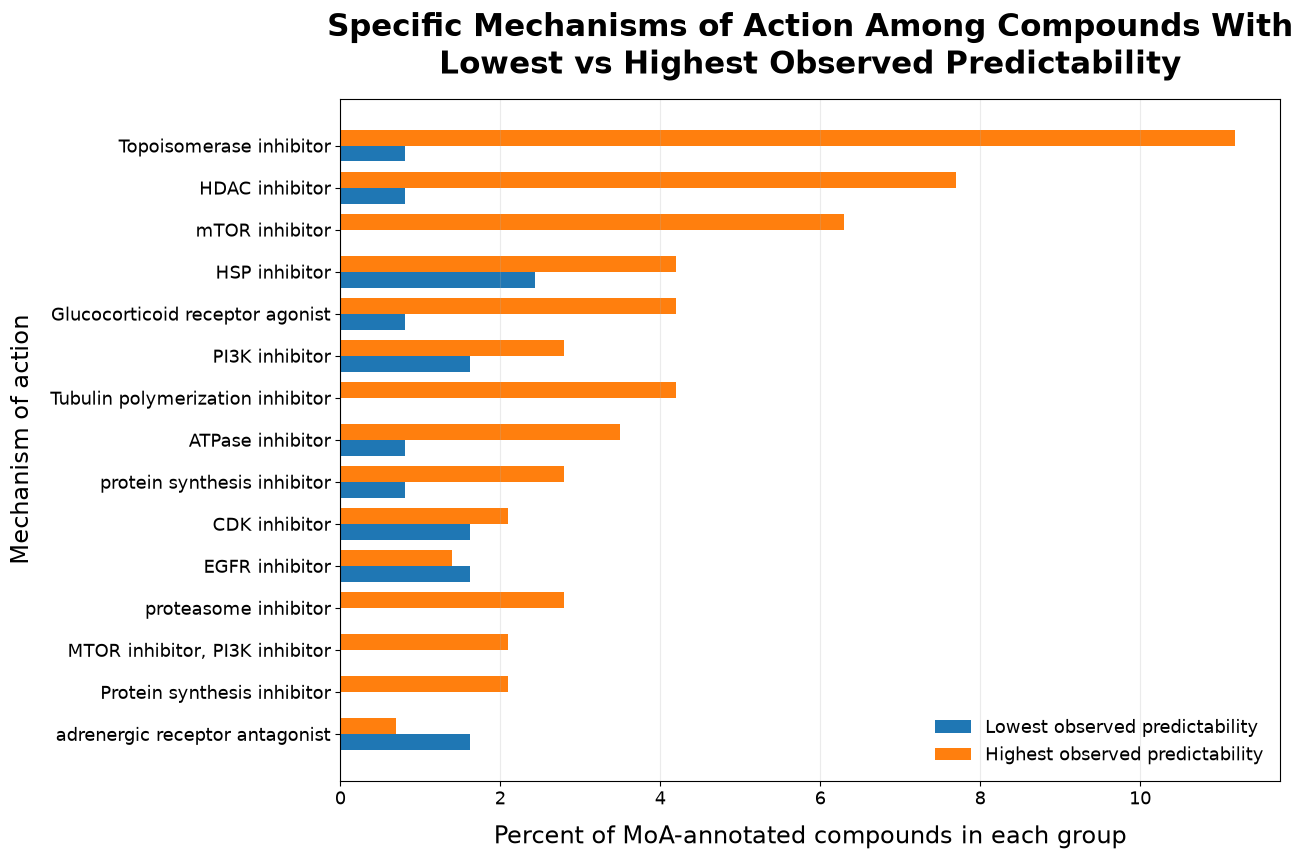


Saved observed MoA table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_observed_specific_moa_comparison.csv

Saved observed MoA figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_specific_moa_lowest_vs_highest.png


In [21]:
# Observed MoA analysis, Step 2

import matplotlib.pyplot as plt



# Count compounds carrying each MoA


observed_moa_counts = pd.crosstab(
    index=(
        observed_moa_long[
            "moa_annotation"
        ]
        .to_numpy()
    ),
    columns=(
        observed_moa_long[
            "observed_predictability_group"
        ]
        .to_numpy()
    ),
)

observed_moa_counts.index.name = (
    "moa_annotation"
)

observed_moa_counts.columns.name = (
    "observed_predictability_group"
)

observed_moa_counts = observed_moa_counts.reindex(
    columns=observed_extreme_groups,
    fill_value=0,
)



# Create comparison table


observed_moa_comparison = (
    observed_moa_counts.copy()
)

observed_moa_comparison.columns = [
    "lowest_observed_count",
    "highest_observed_count",
]

n_observed_low = int(
    observed_annotated_group_sizes[
        "Lowest observed predictability"
    ]
)

n_observed_high = int(
    observed_annotated_group_sizes[
        "Highest observed predictability"
    ]
)

assert n_observed_low > 0
assert n_observed_high > 0


observed_moa_comparison[
    "lowest_observed_percent"
] = (
    100
    * observed_moa_comparison[
        "lowest_observed_count"
    ]
    / n_observed_low
)

observed_moa_comparison[
    "highest_observed_percent"
] = (
    100
    * observed_moa_comparison[
        "highest_observed_count"
    ]
    / n_observed_high
)

observed_moa_comparison[
    "total_extreme_count"
] = (
    observed_moa_comparison[
        "lowest_observed_count"
    ]
    + observed_moa_comparison[
        "highest_observed_count"
    ]
)

observed_moa_comparison = (
    observed_moa_comparison
    .sort_values(
        "total_extreme_count",
        ascending=False,
    )
    .reset_index()
)


print(
    "Most common MoAs among compounds with "
    "extreme observed predictability:"
)

display(
    observed_moa_comparison.head(25)
)


# Select MoAs to show

N_MOAS_TO_PLOT = 15

observed_plot_table = (
    observed_moa_comparison
    .head(N_MOAS_TO_PLOT)
    .sort_values(
        "total_extreme_count",
        ascending=True,
    )
    .copy()
)


# Create bar graph

fig_height = max(
    8,
    0.58 * len(observed_plot_table),
)

fig, ax = plt.subplots(
    figsize=(13, fig_height)
)

positions = np.arange(
    len(observed_plot_table)
)

bar_height = 0.38

ax.barh(
    positions - bar_height / 2,
    observed_plot_table[
        "lowest_observed_percent"
    ],
    height=bar_height,
    label="Lowest observed predictability",
)

ax.barh(
    positions + bar_height / 2,
    observed_plot_table[
        "highest_observed_percent"
    ],
    height=bar_height,
    label="Highest observed predictability",
)

ax.set_yticks(
    positions
)

ax.set_yticklabels(
    observed_plot_table[
        "moa_annotation"
    ],
    fontsize=13,
)

ax.set_xlabel(
    "Percent of MoA-annotated compounds in each group",
    fontsize=17,
    labelpad=12,
)

ax.set_ylabel(
    "Mechanism of action",
    fontsize=17,
    labelpad=12,
)

ax.set_title(
    "Specific Mechanisms of Action Among Compounds With\n"
    "Lowest vs Highest Observed Predictability",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.tick_params(
    axis="x",
    labelsize=13,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.legend(
    fontsize=13,
    frameon=False,
)

fig.tight_layout()


# Save outputs

OBSERVED_MOA_COMPARISON_PATH = (
    OUTPUT_DIR
    / "step4_n20_observed_specific_moa_comparison.csv"
)

OBSERVED_MOA_LONG_PATH = (
    OUTPUT_DIR
    / "step4_n20_observed_specific_moa_long.csv"
)

OBSERVED_MOA_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_observed_specific_moa_lowest_vs_highest.png"
)

OBSERVED_MOA_FIGURE_PDF_PATH = (
    FIG_DIR
    / "step4_n20_observed_specific_moa_lowest_vs_highest.pdf"
)

observed_moa_comparison.to_csv(
    OBSERVED_MOA_COMPARISON_PATH,
    index=False,
)

observed_moa_long.to_csv(
    OBSERVED_MOA_LONG_PATH,
    index=False,
)

fig.savefig(
    OBSERVED_MOA_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    OBSERVED_MOA_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved observed MoA table:")
print(OBSERVED_MOA_COMPARISON_PATH)

print("\nSaved observed MoA figure:")
print(OBSERVED_MOA_FIGURE_PATH)

In [22]:
# Observed MoA analysis, Step 3

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


MIN_TOTAL_COMPOUNDS_PER_MOA = 5

observed_enrichment_rows = []


for _, row in observed_moa_comparison.iterrows():

    moa_name = row["moa_annotation"]

    low_count = int(
        row["lowest_observed_count"]
    )

    high_count = int(
        row["highest_observed_count"]
    )

    total_count = (
        low_count
        + high_count
    )

    if total_count < MIN_TOTAL_COMPOUNDS_PER_MOA:
        continue

    contingency_table = [
        [
            high_count,
            n_observed_high - high_count,
        ],
        [
            low_count,
            n_observed_low - low_count,
        ],
    ]

    odds_ratio, p_value = fisher_exact(
        contingency_table,
        alternative="two-sided",
    )

    corrected_odds_ratio = (
        (high_count + 0.5)
        * (n_observed_low - low_count + 0.5)
        / (
            (n_observed_high - high_count + 0.5)
            * (low_count + 0.5)
        )
    )

    log2_odds_ratio = np.log2(
        corrected_odds_ratio
    )

    if log2_odds_ratio > 0:

        direction = (
            "More common in highest observed"
        )

    elif log2_odds_ratio < 0:

        direction = (
            "More common in lowest observed"
        )

    else:

        direction = "No difference"

    observed_enrichment_rows.append({
        "moa": moa_name,
        "lowest_observed_count": low_count,
        "lowest_observed_total": n_observed_low,
        "highest_observed_count": high_count,
        "highest_observed_total": n_observed_high,
        "total_compounds_with_moa": total_count,
        "fisher_odds_ratio": odds_ratio,
        "corrected_odds_ratio": corrected_odds_ratio,
        "log2_odds_ratio": log2_odds_ratio,
        "p_value": p_value,
        "direction": direction,
    })


observed_moa_enrichment = pd.DataFrame(
    observed_enrichment_rows
)


if len(observed_moa_enrichment) > 0:

    observed_moa_enrichment[
        "adjusted_p_value"
    ] = multipletests(
        observed_moa_enrichment[
            "p_value"
        ],
        method="fdr_bh",
    )[1]

    observed_moa_enrichment[
        "significant_fdr_0_05"
    ] = (
        observed_moa_enrichment[
            "adjusted_p_value"
        ]
        < 0.05
    )

    observed_moa_enrichment = (
        observed_moa_enrichment
        .sort_values(
            [
                "adjusted_p_value",
                "p_value",
            ]
        )
        .reset_index(drop=True)
    )


OBSERVED_MOA_ENRICHMENT_PATH = (
    OUTPUT_DIR
    / "step4_n20_observed_specific_moa_enrichment.csv"
)

observed_moa_enrichment.to_csv(
    OBSERVED_MOA_ENRICHMENT_PATH,
    index=False,
)


print(
    "MoAs tested:",
    len(observed_moa_enrichment),
)

print(
    "Unadjusted p < 0.05:",
    int(
        (
            observed_moa_enrichment[
                "p_value"
            ]
            < 0.05
        ).sum()
    ),
)

print(
    "FDR-adjusted p < 0.05:",
    int(
        observed_moa_enrichment[
            "significant_fdr_0_05"
        ].sum()
    ),
)

display(
    observed_moa_enrichment[
        [
            "moa",
            "lowest_observed_count",
            "highest_observed_count",
            "log2_odds_ratio",
            "p_value",
            "adjusted_p_value",
            "direction",
        ]
    ]
)

print("\nSaved observed enrichment results:")
print(OBSERVED_MOA_ENRICHMENT_PATH)

MoAs tested: 10
Unadjusted p < 0.05: 4
FDR-adjusted p < 0.05: 3


,moa,lowest_observed_count,highest_observed_count,log2_odds_ratio,p_value,adjusted_p_value,direction
0,Topoisomerase inhibitor,1,16,3.401716,0.000567,0.005671,More common in highest observed
1,mTOR inhibitor,0,9,4.124832,0.004147,0.020737,More common in highest observed
2,HDAC inhibitor,1,11,2.825389,0.006834,0.022781,More common in highest observed
3,Tubulin polymerization inhibitor,0,6,3.545519,0.032116,0.080289,More common in highest observed
4,Glucocorticoid receptor agonist,1,6,1.948827,0.127495,0.254989,More common in highest observed
5,ATPase inhibitor,1,5,1.697365,0.221448,0.369081,More common in highest observed
6,protein synthesis inhibitor,1,4,1.397479,0.377410,0.539157,More common in highest observed
7,HSP inhibitor,3,6,0.702686,0.511717,0.639646,More common in highest observed
8,PI3K inhibitor,2,4,0.648688,0.689333,0.765926,More common in highest observed
9,CDK inhibitor,2,3,0.275813,1.000000,1.000000,More common in highest observed



Saved observed enrichment results:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_observed_specific_moa_enrichment.csv


In [23]:
# Compare 

predicted_comparison = (
    predicted_moa_enrichment[
        [
            "moa",
            "log2_odds_ratio",
            "adjusted_p_value",
            "direction",
        ]
    ]
    .rename(
        columns={
            "log2_odds_ratio":
                "predicted_log2_odds_ratio",
            "adjusted_p_value":
                "predicted_adjusted_p_value",
            "direction":
                "predicted_direction",
        }
    )
)

observed_comparison = (
    observed_moa_enrichment[
        [
            "moa",
            "log2_odds_ratio",
            "adjusted_p_value",
            "direction",
        ]
    ]
    .rename(
        columns={
            "log2_odds_ratio":
                "observed_log2_odds_ratio",
            "adjusted_p_value":
                "observed_adjusted_p_value",
            "direction":
                "observed_direction",
        }
    )
)

model_observed_moa_comparison = (
    predicted_comparison
    .merge(
        observed_comparison,
        on="moa",
        how="outer",
    )
)


model_observed_moa_comparison[
    "significant_in_predicted_analysis"
] = (
    model_observed_moa_comparison[
        "predicted_adjusted_p_value"
    ]
    < 0.05
)

model_observed_moa_comparison[
    "significant_in_observed_analysis"
] = (
    model_observed_moa_comparison[
        "observed_adjusted_p_value"
    ]
    < 0.05
)

model_observed_moa_comparison[
    "same_effect_direction"
] = (
    np.sign(
        model_observed_moa_comparison[
            "predicted_log2_odds_ratio"
        ]
    )
    ==
    np.sign(
        model_observed_moa_comparison[
            "observed_log2_odds_ratio"
        ]
    )
)

model_observed_moa_comparison = (
    model_observed_moa_comparison
    .sort_values(
        [
            "significant_in_observed_analysis",
            "observed_adjusted_p_value",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


MODEL_OBSERVED_COMPARISON_PATH = (
    OUTPUT_DIR
    / "step4_n20_predicted_vs_observed_moa_comparison.csv"
)

model_observed_moa_comparison.to_csv(
    MODEL_OBSERVED_COMPARISON_PATH,
    index=False,
)


display(
    model_observed_moa_comparison
)

print("\nSaved model-versus-observed comparison:")
print(MODEL_OBSERVED_COMPARISON_PATH)

,moa,predicted_log2_odds_ratio,predicted_adjusted_p_value,predicted_direction,observed_log2_odds_ratio,observed_adjusted_p_value,observed_direction,significant_in_predicted_analysis,significant_in_observed_analysis,same_effect_direction
0,Topoisomerase inhibitor,3.403315,0.002124,More common in most predictable,3.401716,0.005671,More common in highest observed,True,True,True
1,mTOR inhibitor,3.645786,0.043273,More common in most predictable,4.124832,0.020737,More common in highest observed,True,True,True
2,HDAC inhibitor,-1.737540,0.246919,More common in least predictable,2.825389,0.022781,More common in highest observed,False,True,False
3,Tubulin polymerization inhibitor,1.497830,0.413811,More common in most predictable,3.545519,0.080289,More common in highest observed,False,False,True
4,Glucocorticoid receptor agonist,4.655040,0.002124,More common in most predictable,1.948827,0.254989,More common in highest observed,True,False,True
5,ATPase inhibitor,3.863003,0.040570,More common in most predictable,1.697365,0.369081,More common in highest observed,True,False,True
6,protein synthesis inhibitor,NaN,NaN,NaN,1.397479,0.539157,More common in highest observed,False,False,False
7,HSP inhibitor,NaN,NaN,NaN,0.702686,0.639646,More common in highest observed,False,False,False
8,PI3K inhibitor,NaN,NaN,NaN,0.648688,0.765926,More common in highest observed,False,False,False
9,CDK inhibitor,NaN,NaN,NaN,0.275813,1.000000,More common in highest observed,False,False,False



Saved model-versus-observed comparison:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_predicted_vs_observed_moa_comparison.csv


In [24]:
# Rebuild clean MoA annotations for both predicted and observed analyses

import re
import numpy as np
import pandas as pd


# Values that should not be treated as real MoA annotations

MISSING_MOA_VALUES = {
    "",
    "nan",
    "none",
    "<na>",
    "na",
    "n/a",
    "-",
}


NON_SPECIFIC_MOAS = {
    "Unclear",
    "Inhibitor/antagonist",
    "Activator/agonist",
}


# Canonical names for common annotations and acronyms

CANONICAL_MOA_NAMES = {
    "akt inhibitor":
        "AKT inhibitor",

    "atpase inhibitor":
        "ATPase inhibitor",

    "aurora kinase inhibitor":
        "Aurora kinase inhibitor",

    "bacterial 30s ribosomal subunit inhibitor":
        "Bacterial 30S ribosomal subunit inhibitor",

    "bruton's tyrosine kinase (btk) inhibitor":
        "Bruton's tyrosine kinase (BTK) inhibitor",

    "cdk inhibitor":
        "CDK inhibitor",

    "dna polymerase inhibitor":
        "DNA polymerase inhibitor",

    "dopamine receptor antagonist":
        "Dopamine receptor antagonist",

    "egfr inhibitor":
        "EGFR inhibitor",

    "flt3 inhibitor":
        "FLT3 inhibitor",

    "glucocorticoid receptor agonist":
        "Glucocorticoid receptor agonist",

    "glycogen synthase kinase inhibitor":
        "Glycogen synthase kinase inhibitor",

    "hdac inhibitor":
        "HDAC inhibitor",

    "hmgcr inhibitor":
        "HMGCR inhibitor",

    "hsp inhibitor":
        "HSP inhibitor",

    "ikk inhibitor":
        "IKK inhibitor",

    "inhibitors of signal transduction pathways":
        "Inhibitors of signal transduction pathways",

    "map kinase inhibitor":
        "MAP kinase inhibitor",

    "mek inhibitor":
        "MEK inhibitor",

    "microtubule inhibitor":
        "Microtubule inhibitor",

    "mtor inhibitor":
        "mTOR inhibitor",

    "pi3k inhibitor":
        "PI3K inhibitor",

    "protein synthesis inhibitor":
        "Protein synthesis inhibitor",

    "proteasome inhibitor":
        "Proteasome inhibitor",

    "retinoid receptor agonist":
        "Retinoid receptor agonist",

    "rna polymerase inhibitor":
        "RNA polymerase inhibitor",

    "topoisomerase inhibitor":
        "Topoisomerase inhibitor",

    "tubulin inhibitor":
        "Tubulin inhibitor",

    "tubulin polymerization inhibitor":
        "Tubulin polymerization inhibitor",

    "tyrosine kinase inhibitor":
        "Tyrosine kinase inhibitor",

    "adrenergic receptor agonist":
        "Adrenergic receptor agonist",

    "adrenergic receptor antagonist":
        "Adrenergic receptor antagonist",

    "inhibitor/antagonist":
        "Inhibitor/antagonist",

    "activator/agonist":
        "Activator/agonist",

    "unclear":
        "Unclear",
}


# Universal MoA parser

def parse_and_standardize_moas(value):
    """
    Split one compound's MoA field into clean, distinct annotations.

    The source registry may join annotations with:
    - semicolons
    - vertical pipes
    - commas

    Capitalization and known acronym variants standardized.
    """

    if pd.isna(value):
        return []

    text = str(value).strip()

    if text.casefold() in MISSING_MOA_VALUES:
        return []

    # Normalize unusual separators before splitting
    text = (
        text
        .replace("\n", ";")
        .replace("｜", "|")
    )

    raw_annotations = re.split(
        r"\s*[;|,]\s*",
        text,
    )

    cleaned_annotations = []

    for annotation in raw_annotations:

        annotation = re.sub(
            r"\s+",
            " ",
            annotation,
        ).strip()

        if not annotation:
            continue

        annotation_key = annotation.casefold()

        if annotation_key in MISSING_MOA_VALUES:
            continue

        canonical_annotation = (
            CANONICAL_MOA_NAMES.get(
                annotation_key,
                annotation,
            )
        )

        if canonical_annotation in NON_SPECIFIC_MOAS:
            continue

        cleaned_annotations.append(
            canonical_annotation
        )

    # Prevent one compound from being counted twice for the same MoA
    return sorted(
        set(cleaned_annotations)
    )


# Recreate predicted groups from out-of-fold model predictions

predicted_group_labels = [
    "Least predictable",
    "Lower",
    "Middle",
    "Higher",
    "Most predictable",
]

predicted_rank = (
    moa_results["predicted_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

moa_results["model_prediction_group"] = pd.qcut(
    predicted_rank,
    q=5,
    labels=predicted_group_labels,
)


# Recreate observed groups from actual Step 3 scores

observed_group_labels = [
    "Lowest observed predictability",
    "Lower",
    "Middle",
    "Higher",
    "Highest observed predictability",
]

observed_rank = (
    moa_results["actual_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

moa_results["observed_predictability_group"] = pd.qcut(
    observed_rank,
    q=5,
    labels=observed_group_labels,
)


# Create one clean long-format MoA table

all_moa_long = (
    moa_results[
        [
            "compound_embedding_row_index",
            "compound_name",
            "n_profiles",
            "actual_predictability",
            "predicted_predictability",
            "model_prediction_group",
            "observed_predictability_group",
            "moa",
        ]
    ]
    .assign(
        moa_annotation=lambda frame:
            frame["moa"].apply(
                parse_and_standardize_moas
            )
    )
    .explode("moa_annotation")
    .dropna(subset=["moa_annotation"])
    .copy()
)

all_moa_long["moa_annotation"] = (
    all_moa_long["moa_annotation"]
    .astype(str)
    .str.strip()
)

all_moa_long = (
    all_moa_long
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "moa_annotation",
        ]
    )
    .reset_index(drop=True)
)


# Verify that combined labels were actually separated

remaining_separator_mask = (
    all_moa_long["moa_annotation"]
    .str.contains(
        r"[;|,]",
        regex=True,
        na=False,
    )
)

remaining_combined_labels = (
    all_moa_long.loc[
        remaining_separator_mask,
        "moa_annotation",
    ]
    .value_counts()
)

print("Clean MoA table created")
print("-" * 55)

print(
    "Compounds with at least one specific MoA:",
    all_moa_long[
        "compound_embedding_row_index"
    ].nunique(),
)

print(
    "Unique standardized MoAs:",
    all_moa_long[
        "moa_annotation"
    ].nunique(),
)

print(
    "Annotations still containing separators:",
    int(remaining_separator_mask.sum()),
)

if len(remaining_combined_labels) > 0:
    display(
        remaining_combined_labels
        .rename("count")
        .reset_index()
    )

else:
    print(
        "No semicolon-, pipe-, or comma-combined labels remain."
    )


print("\nMost common cleaned MoAs:")

display(
    all_moa_long[
        "moa_annotation"
    ]
    .value_counts()
    .head(30)
    .rename("compound_annotations")
    .reset_index()
)

Clean MoA table created
-------------------------------------------------------
Compounds with at least one specific MoA: 660
Unique standardized MoAs: 478
Annotations still containing separators: 0
No semicolon-, pipe-, or comma-combined labels remain.

Most common cleaned MoAs:


,moa_annotation,compound_annotations
0,Topoisomerase inhibitor,22
1,Glucocorticoid receptor agonist,21
2,PI3K inhibitor,19
3,EGFR inhibitor,19
4,HDAC inhibitor,19
5,Aurora kinase inhibitor,17
6,CDK inhibitor,17
7,mTOR inhibitor,17
8,Tubulin polymerization inhibitor,16
9,VEGFR inhibitor,15


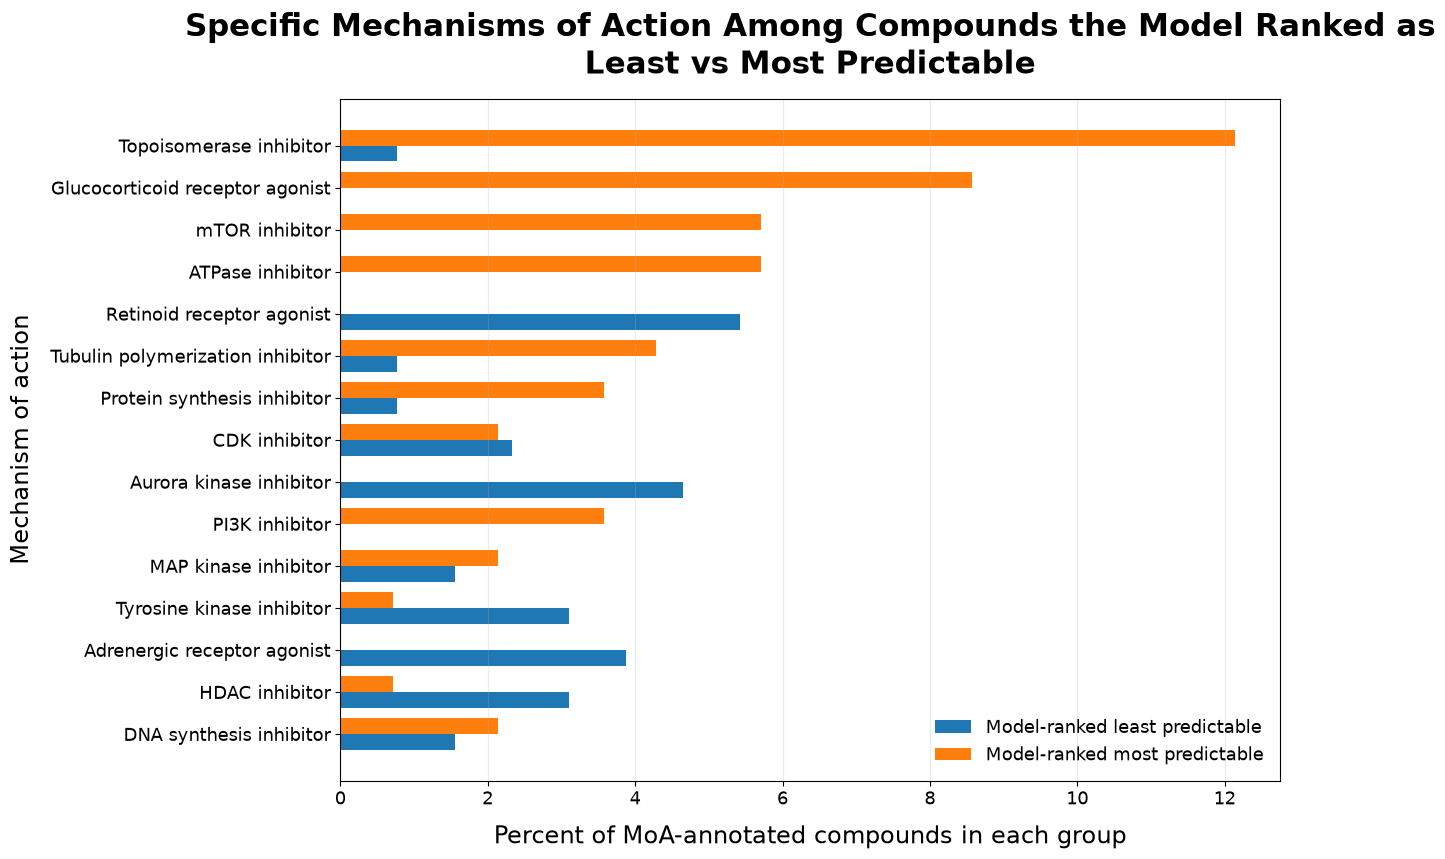


Specific Mechanisms of Action Among Compounds the Model Ranked as Least vs Most Predictable
Model-ranked least predictable: 129 MoA-annotated compounds
Model-ranked most predictable: 140 MoA-annotated compounds
MoAs formally tested: 18
FDR-significant MoAs: 6


,moa,low_count,high_count,log2_odds_ratio,p_value,adjusted_p_value,direction
0,Topoisomerase inhibitor,1,17,3.601578,0.000111,0.001997,More common in Model-ranked most predictable
1,Glucocorticoid receptor agonist,0,12,4.655040,0.000424,0.003815,More common in Model-ranked most predictable
2,Retinoid receptor agonist,7,0,-4.104679,0.005347,0.026522,More common in Model-ranked least predictable
3,ATPase inhibitor,0,8,4.054423,0.007367,0.026522,More common in Model-ranked most predictable
4,mTOR inhibitor,0,8,4.054423,0.007367,0.026522,More common in Model-ranked most predictable
5,Aurora kinase inhibitor,6,0,-3.886499,0.011433,0.034300,More common in Model-ranked least predictable
6,Adrenergic receptor agonist,5,0,-3.633856,0.024342,0.054770,More common in Model-ranked least predictable
7,Glycogen synthase kinase inhibitor,5,0,-3.633856,0.024342,0.054770,More common in Model-ranked least predictable
8,PI3K inhibitor,0,5,3.394091,0.061219,0.110194,More common in Model-ranked most predictable
9,Bacterial 30S ribosomal subunit inhibitor,0,5,3.394091,0.061219,0.110194,More common in Model-ranked most predictable


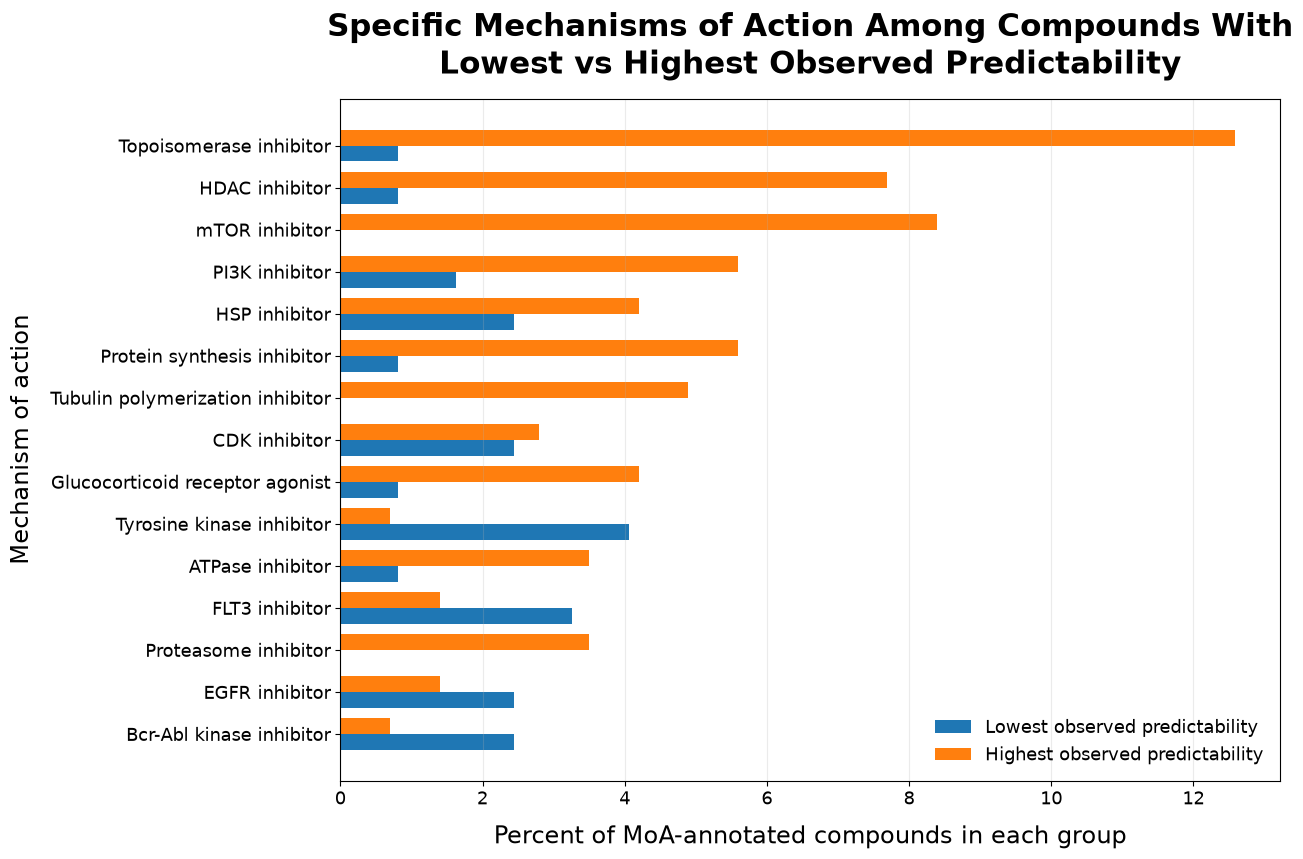


Specific Mechanisms of Action Among Compounds With Lowest vs Highest Observed Predictability
Lowest observed predictability: 123 MoA-annotated compounds
Highest observed predictability: 143 MoA-annotated compounds
MoAs formally tested: 14
FDR-significant MoAs: 3


,moa,low_count,high_count,log2_odds_ratio,p_value,adjusted_p_value,direction
0,Topoisomerase inhibitor,1,18,3.589585,0.000148,0.002067,More common in Highest observed predictability
1,mTOR inhibitor,0,12,4.553304,0.000537,0.003759,More common in Highest observed predictability
2,HDAC inhibitor,1,11,2.825389,0.006834,0.031893,More common in Highest observed predictability
3,Tubulin polymerization inhibitor,0,7,3.762501,0.016219,0.056768,More common in Highest observed predictability
4,Protein synthesis inhibitor,1,8,2.356989,0.040612,0.113715,More common in Highest observed predictability
5,Proteasome inhibitor,0,5,3.294057,0.063671,0.148566,More common in Highest observed predictability
6,Tyrosine kinase inhibitor,5,1,-2.140544,0.098587,0.197175,More common in Lowest observed predictability
7,PI3K inhibitor,2,8,1.608198,0.112715,0.197250,More common in Highest observed predictability
8,Glucocorticoid receptor agonist,1,6,1.948827,0.127495,0.198325,More common in Highest observed predictability
9,ATPase inhibitor,1,5,1.697365,0.221448,0.310028,More common in Highest observed predictability


In [25]:
# Recalculate MoA counts, enrichment, and figures using the fully cleaned annotations 

import matplotlib.pyplot as plt

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


def run_clean_moa_analysis(
    moa_long,
    group_column,
    low_group,
    high_group,
    low_display_label,
    high_display_label,
    title,
    output_prefix,
    minimum_total_count=5,
    number_to_plot=15,
):
    """
    Compare MoAs, run Fisher, make a bar graph, and save.
    """


    # Keep only the two extreme groups


    extreme_long = (
        moa_long[
            moa_long[group_column].isin(
                [
                    low_group,
                    high_group,
                ]
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    extreme_long[group_column] = (
        extreme_long[group_column]
        .astype(str)
    )



    # Count MoA-annotated compounds in each group


    group_sizes = (
        extreme_long
        .groupby(group_column)[
            "compound_embedding_row_index"
        ]
        .nunique()
        .reindex(
            [
                low_group,
                high_group,
            ]
        )
    )

    n_low = int(
        group_sizes.loc[low_group]
    )

    n_high = int(
        group_sizes.loc[high_group]
    )

    assert n_low > 0
    assert n_high > 0



    # Count compounds carrying each MoA


    counts = pd.crosstab(
        index=(
            extreme_long["moa_annotation"]
            .to_numpy()
        ),
        columns=(
            extreme_long[group_column]
            .to_numpy()
        ),
    )

    counts.index.name = "moa_annotation"

    counts = counts.reindex(
        columns=[
            low_group,
            high_group,
        ],
        fill_value=0,
    )

    comparison = counts.copy()

    comparison.columns = [
        "low_count",
        "high_count",
    ]

    comparison["low_percent"] = (
        100
        * comparison["low_count"]
        / n_low
    )

    comparison["high_percent"] = (
        100
        * comparison["high_count"]
        / n_high
    )

    comparison["total_extreme_count"] = (
        comparison["low_count"]
        + comparison["high_count"]
    )

    comparison = (
        comparison
        .sort_values(
            "total_extreme_count",
            ascending=False,
        )
        .reset_index()
    )



    # Fisher enrichment analysis


    enrichment_rows = []

    for _, row in comparison.iterrows():

        low_count = int(
            row["low_count"]
        )

        high_count = int(
            row["high_count"]
        )

        total_count = (
            low_count
            + high_count
        )

        if total_count < minimum_total_count:
            continue

        contingency_table = [
            [
                high_count,
                n_high - high_count,
            ],
            [
                low_count,
                n_low - low_count,
            ],
        ]

        fisher_odds_ratio, p_value = (
            fisher_exact(
                contingency_table,
                alternative="two-sided",
            )
        )

        corrected_odds_ratio = (
            (high_count + 0.5)
            * (n_low - low_count + 0.5)
            / (
                (n_high - high_count + 0.5)
                * (low_count + 0.5)
            )
        )

        log2_odds_ratio = np.log2(
            corrected_odds_ratio
        )

        if log2_odds_ratio > 0:
            direction = (
                f"More common in {high_display_label}"
            )

        elif log2_odds_ratio < 0:
            direction = (
                f"More common in {low_display_label}"
            )

        else:
            direction = "No difference"

        enrichment_rows.append({
            "moa": row["moa_annotation"],
            "low_count": low_count,
            "low_total": n_low,
            "high_count": high_count,
            "high_total": n_high,
            "total_extreme_count": total_count,
            "fisher_odds_ratio":
                fisher_odds_ratio,
            "corrected_odds_ratio":
                corrected_odds_ratio,
            "log2_odds_ratio":
                log2_odds_ratio,
            "p_value": p_value,
            "direction": direction,
        })

    enrichment = pd.DataFrame(
        enrichment_rows
    )

    if len(enrichment) > 0:

        enrichment["adjusted_p_value"] = (
            multipletests(
                enrichment["p_value"],
                method="fdr_bh",
            )[1]
        )

        enrichment[
            "significant_fdr_0_05"
        ] = (
            enrichment["adjusted_p_value"]
            < 0.05
        )

        enrichment = (
            enrichment
            .sort_values(
                [
                    "adjusted_p_value",
                    "p_value",
                ]
            )
            .reset_index(drop=True)
        )



    # Make cleaned bar graph


    plot_table = (
        comparison
        .head(number_to_plot)
        .sort_values(
            "total_extreme_count",
            ascending=True,
        )
        .copy()
    )

    figure_height = max(
        8,
        0.58 * len(plot_table),
    )

    fig, ax = plt.subplots(
        figsize=(13, figure_height)
    )

    positions = np.arange(
        len(plot_table)
    )

    bar_height = 0.38

    ax.barh(
        positions - bar_height / 2,
        plot_table["low_percent"],
        height=bar_height,
        label=low_display_label,
    )

    ax.barh(
        positions + bar_height / 2,
        plot_table["high_percent"],
        height=bar_height,
        label=high_display_label,
    )

    ax.set_yticks(
        positions
    )

    ax.set_yticklabels(
        plot_table["moa_annotation"],
        fontsize=13,
    )

    ax.set_xlabel(
        "Percent of MoA-annotated compounds in each group",
        fontsize=17,
        labelpad=12,
    )

    ax.set_ylabel(
        "Mechanism of action",
        fontsize=17,
        labelpad=12,
    )

    ax.set_title(
        title,
        fontsize=22,
        fontweight="bold",
        pad=18,
    )

    ax.tick_params(
        axis="x",
        labelsize=13,
    )

    ax.grid(
        axis="x",
        alpha=0.25,
    )

    ax.legend(
        fontsize=13,
        frameon=False,
    )

    fig.tight_layout()



    # Save outputs


    comparison_path = (
        OUTPUT_DIR
        / f"{output_prefix}_moa_comparison.csv"
    )

    enrichment_path = (
        OUTPUT_DIR
        / f"{output_prefix}_moa_enrichment.csv"
    )

    long_path = (
        OUTPUT_DIR
        / f"{output_prefix}_moa_long.csv"
    )

    figure_path = (
        FIG_DIR
        / f"{output_prefix}_moa_comparison.png"
    )

    figure_pdf_path = (
        FIG_DIR
        / f"{output_prefix}_moa_comparison.pdf"
    )

    comparison.to_csv(
        comparison_path,
        index=False,
    )

    enrichment.to_csv(
        enrichment_path,
        index=False,
    )

    extreme_long.to_csv(
        long_path,
        index=False,
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        figure_pdf_path,
        bbox_inches="tight",
    )

    plt.show()



    # Display summary


    print("\n" + "=" * 65)
    print(title.replace("\n", " "))
    print("=" * 65)

    print(
        f"{low_display_label}: "
        f"{n_low} MoA-annotated compounds"
    )

    print(
        f"{high_display_label}: "
        f"{n_high} MoA-annotated compounds"
    )

    print(
        "MoAs formally tested:",
        len(enrichment),
    )

    print(
        "FDR-significant MoAs:",
        int(
            enrichment[
                "significant_fdr_0_05"
            ].sum()
        ),
    )

    display(
        enrichment[
            [
                "moa",
                "low_count",
                "high_count",
                "log2_odds_ratio",
                "p_value",
                "adjusted_p_value",
                "direction",
            ]
        ]
    )

    return {
        "comparison": comparison,
        "enrichment": enrichment,
        "long": extreme_long,
        "group_sizes": group_sizes,
        "figure_path": figure_path,
    }



# Analysis A: groups created by the regression model


predicted_clean_analysis = run_clean_moa_analysis(
    moa_long=all_moa_long,
    group_column="model_prediction_group",
    low_group="Least predictable",
    high_group="Most predictable",
    low_display_label=(
        "Model-ranked least predictable"
    ),
    high_display_label=(
        "Model-ranked most predictable"
    ),
    title=(
        "Specific Mechanisms of Action Among Compounds the Model Ranked as\n"
        "Least vs Most Predictable"
    ),
    output_prefix=(
        "step4_n20_clean_predicted"
    ),
)



# Analysis B: groups created using actual observed scores


observed_clean_analysis = run_clean_moa_analysis(
    moa_long=all_moa_long,
    group_column="observed_predictability_group",
    low_group=(
        "Lowest observed predictability"
    ),
    high_group=(
        "Highest observed predictability"
    ),
    low_display_label=(
        "Lowest observed predictability"
    ),
    high_display_label=(
        "Highest observed predictability"
    ),
    title=(
        "Specific Mechanisms of Action Among Compounds With\n"
        "Lowest vs Highest Observed Predictability"
    ),
    output_prefix=(
        "step4_n20_clean_observed"
    ),
)

In [26]:
# Compare the fully cleaned predicted and observed MoA results

predicted_enrichment_clean = (
    predicted_clean_analysis[
        "enrichment"
    ]
    .copy()
)

observed_enrichment_clean = (
    observed_clean_analysis[
        "enrichment"
    ]
    .copy()
)


predicted_for_merge = (
    predicted_enrichment_clean[
        [
            "moa",
            "low_count",
            "high_count",
            "log2_odds_ratio",
            "adjusted_p_value",
            "significant_fdr_0_05",
            "direction",
        ]
    ]
    .rename(
        columns={
            "low_count":
                "predicted_low_count",

            "high_count":
                "predicted_high_count",

            "log2_odds_ratio":
                "predicted_log2_odds_ratio",

            "adjusted_p_value":
                "predicted_adjusted_p_value",

            "significant_fdr_0_05":
                "significant_in_predicted_analysis",

            "direction":
                "predicted_direction",
        }
    )
)


observed_for_merge = (
    observed_enrichment_clean[
        [
            "moa",
            "low_count",
            "high_count",
            "log2_odds_ratio",
            "adjusted_p_value",
            "significant_fdr_0_05",
            "direction",
        ]
    ]
    .rename(
        columns={
            "low_count":
                "observed_low_count",

            "high_count":
                "observed_high_count",

            "log2_odds_ratio":
                "observed_log2_odds_ratio",

            "adjusted_p_value":
                "observed_adjusted_p_value",

            "significant_fdr_0_05":
                "significant_in_observed_analysis",

            "direction":
                "observed_direction",
        }
    )
)


clean_model_observed_comparison = (
    predicted_for_merge
    .merge(
        observed_for_merge,
        on="moa",
        how="outer",
    )
)


# Mark whether each MoA was actually tested

clean_model_observed_comparison[
    "tested_in_predicted_analysis"
] = (
    clean_model_observed_comparison[
        "predicted_adjusted_p_value"
    ]
    .notna()
)

clean_model_observed_comparison[
    "tested_in_observed_analysis"
] = (
    clean_model_observed_comparison[
        "observed_adjusted_p_value"
    ]
    .notna()
)


clean_model_observed_comparison[
    "significant_in_predicted_analysis"
] = (
    clean_model_observed_comparison[
        "significant_in_predicted_analysis"
    ]
    .fillna(False)
    .astype(bool)
)

clean_model_observed_comparison[
    "significant_in_observed_analysis"
] = (
    clean_model_observed_comparison[
        "significant_in_observed_analysis"
    ]
    .fillna(False)
    .astype(bool)
)


# Compare effect 

tested_in_both = (
    clean_model_observed_comparison[
        "tested_in_predicted_analysis"
    ]
    &
    clean_model_observed_comparison[
        "tested_in_observed_analysis"
    ]
)

clean_model_observed_comparison[
    "same_effect_direction"
] = pd.Series(
    pd.NA,
    index=clean_model_observed_comparison.index,
    dtype="boolean",
)

clean_model_observed_comparison.loc[
    tested_in_both,
    "same_effect_direction",
] = (
    np.sign(
        clean_model_observed_comparison.loc[
            tested_in_both,
            "predicted_log2_odds_ratio",
        ]
    )
    ==
    np.sign(
        clean_model_observed_comparison.loc[
            tested_in_both,
            "observed_log2_odds_ratio",
        ]
    )
)



clean_model_observed_comparison[
    "model_recovered_observed_moa_pattern"
] = (
    clean_model_observed_comparison[
        "significant_in_predicted_analysis"
    ]
    &
    clean_model_observed_comparison[
        "significant_in_observed_analysis"
    ]
    &
    clean_model_observed_comparison[
        "same_effect_direction"
    ].fillna(False)
)


clean_model_observed_comparison = (
    clean_model_observed_comparison
    .sort_values(
        [
            "model_recovered_observed_moa_pattern",
            "significant_in_observed_analysis",
            "observed_adjusted_p_value",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


CLEAN_MODEL_OBSERVED_PATH = (
    OUTPUT_DIR
    / "step4_n20_clean_predicted_vs_observed_moa.csv"
)

clean_model_observed_comparison.to_csv(
    CLEAN_MODEL_OBSERVED_PATH,
    index=False,
)


display(
    clean_model_observed_comparison
)

print("\nMoA patterns recovered by the model:")

display(
    clean_model_observed_comparison[
        clean_model_observed_comparison[
            "model_recovered_observed_moa_pattern"
        ]
    ]
)

print("\nSaved corrected comparison:")
print(CLEAN_MODEL_OBSERVED_PATH)

,moa,predicted_low_count,predicted_high_count,predicted_log2_odds_ratio,predicted_adjusted_p_value,significant_in_predicted_analysis,predicted_direction,observed_low_count,observed_high_count,observed_log2_odds_ratio,observed_adjusted_p_value,significant_in_observed_analysis,observed_direction,tested_in_predicted_analysis,tested_in_observed_analysis,same_effect_direction,model_recovered_observed_moa_pattern
0,Topoisomerase inhibitor,1.0,17.0,3.601578,0.001997,True,More common in Model-ranked most predictable,1.0,18.0,3.589585,0.002067,True,More common in Highest observed predictability,True,True,True,True
1,mTOR inhibitor,0.0,8.0,4.054423,0.026522,True,More common in Model-ranked most predictable,0.0,12.0,4.553304,0.003759,True,More common in Highest observed predictability,True,True,True,True
2,HDAC inhibitor,4.0,1.0,-1.737540,0.273510,False,More common in Model-ranked least predictable,1.0,11.0,2.825389,0.031893,True,More common in Highest observed predictability,True,True,False,False
3,Tubulin polymerization inhibitor,1.0,6.0,2.049639,0.200136,False,More common in Model-ranked most predictable,0.0,7.0,3.762501,0.056768,False,More common in Highest observed predictability,True,True,True,False
4,Protein synthesis inhibitor,1.0,5.0,1.797945,0.277534,False,More common in Model-ranked most predictable,1.0,8.0,2.356989,0.113715,False,More common in Highest observed predictability,True,True,True,False
5,Proteasome inhibitor,NaN,NaN,NaN,NaN,False,NaN,0.0,5.0,3.294057,0.148566,False,More common in Highest observed predictability,False,True,<NA>,False
6,Tyrosine kinase inhibitor,4.0,1.0,-1.737540,0.273510,False,More common in Model-ranked least predictable,5.0,1.0,-2.140544,0.197175,False,More common in Lowest observed predictability,True,True,True,False
7,PI3K inhibitor,0.0,5.0,3.394091,0.110194,False,More common in Model-ranked most predictable,2.0,8.0,1.608198,0.197250,False,More common in Highest observed predictability,True,True,True,False
8,Glucocorticoid receptor agonist,0.0,12.0,4.655040,0.003815,True,More common in Model-ranked most predictable,1.0,6.0,1.948827,0.198325,False,More common in Highest observed predictability,True,True,True,False
9,ATPase inhibitor,0.0,8.0,4.054423,0.026522,True,More common in Model-ranked most predictable,1.0,5.0,1.697365,0.310028,False,More common in Highest observed predictability,True,True,True,False



MoA patterns recovered by the model:


,moa,predicted_low_count,predicted_high_count,predicted_log2_odds_ratio,predicted_adjusted_p_value,significant_in_predicted_analysis,predicted_direction,observed_low_count,observed_high_count,observed_log2_odds_ratio,observed_adjusted_p_value,significant_in_observed_analysis,observed_direction,tested_in_predicted_analysis,tested_in_observed_analysis,same_effect_direction,model_recovered_observed_moa_pattern
0,Topoisomerase inhibitor,1.0,17.0,3.601578,0.001997,True,More common in Model-ranked most predictable,1.0,18.0,3.589585,0.002067,True,More common in Highest observed predictability,True,True,True,True
1,mTOR inhibitor,0.0,8.0,4.054423,0.026522,True,More common in Model-ranked most predictable,0.0,12.0,4.553304,0.003759,True,More common in Highest observed predictability,True,True,True,True



Saved corrected comparison:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_clean_predicted_vs_observed_moa.csv


In [27]:
# Verify 

from pathlib import Path


# Find the notebook

notebook_matches = list(
    PROJECT_ROOT.rglob(
        "step4_expanded_regression_moa.ipynb"
    )
)

print("Notebook matches:")
for path in notebook_matches:
    print(" ", path)


# Final figures that should exist

expected_figures = [
    FIG_DIR
    / "step4_n20_observed_by_predicted_quintile.png",

    FIG_DIR
    / "step4_n20_observed_by_predicted_quintile.pdf",

    FIG_DIR
    / "step4_n20_clean_predicted_moa_comparison.png",

    FIG_DIR
    / "step4_n20_clean_predicted_moa_comparison.pdf",

    FIG_DIR
    / "step4_n20_clean_observed_moa_comparison.png",

    FIG_DIR
    / "step4_n20_clean_observed_moa_comparison.pdf",
]


# Final result tables that should exist

expected_tables = [
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions.csv",

    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions_with_groups.csv",

    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_summary_metrics.csv",

    OUTPUT_DIR
    / "step4_n20_predicted_quintile_summary.csv",

    OUTPUT_DIR
    / "step4_n20_clean_predicted_moa_comparison.csv",

    OUTPUT_DIR
    / "step4_n20_clean_predicted_moa_enrichment.csv",

    OUTPUT_DIR
    / "step4_n20_clean_observed_moa_comparison.csv",

    OUTPUT_DIR
    / "step4_n20_clean_observed_moa_enrichment.csv",

    OUTPUT_DIR
    / "step4_n20_clean_predicted_vs_observed_moa.csv",
]


# Check every expected file

all_expected_files = (
    expected_figures
    + expected_tables
)

missing_files = []
empty_files = []

for path in all_expected_files:

    if not path.exists():
        status = "MISSING"
        missing_files.append(path)

    elif path.stat().st_size == 0:
        status = "EMPTY"
        empty_files.append(path)

    else:
        size_mb = path.stat().st_size / 1e6
        status = f"OK — {size_mb:.3f} MB"

    print(f"{status:20} {path}")


print("\n" + "=" * 70)

if not notebook_matches:
    print("WARNING: Final notebook was not found.")

if missing_files:
    print(
        f"WARNING: {len(missing_files)} expected files are missing."
    )

if empty_files:
    print(
        f"WARNING: {len(empty_files)} files are empty."
    )

if (
    notebook_matches
    and not missing_files
    and not empty_files
):
    print(
        "Everything is saved and ready for GitHub."
    )

Notebook matches:
  /Users/mell/predicting-predictability/data/step4_expanded_regression_moa.ipynb
OK — 0.499 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_by_predicted_quintile.png
OK — 0.048 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_by_predicted_quintile.pdf
OK — 0.317 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_clean_predicted_moa_comparison.png
OK — 0.029 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_clean_predicted_moa_comparison.pdf
OK — 0.285 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_clean_observed_moa_comparison.png
OK — 0.032 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_clean_observed_moa_comparison.pdf
OK — 0.116 MB        /Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_extra_trees